# Quantitative Analysis - Snowflake for Finance 


---

<h1 style='text-align: center;'>Case 1 - META</h1>

---

In [ ]:

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from snowflake.snowpark.context import get_active_session
from snowflake.snowpark import Session


connection_parameters = {
   "account": "******-*****",
   "user": "******",
   "password": "******",
   "role": "accountadmin", 
   "warehouse": "TEST", 
   "database": "TIME_SERIES_ANALYTICS",
   "schema": "PUBLIC",
   }

session = Session.builder.configs(connection_parameters).create()


# Data Ingestion, Transformations & Engineering 
  


No handles with labels found to put in legend.


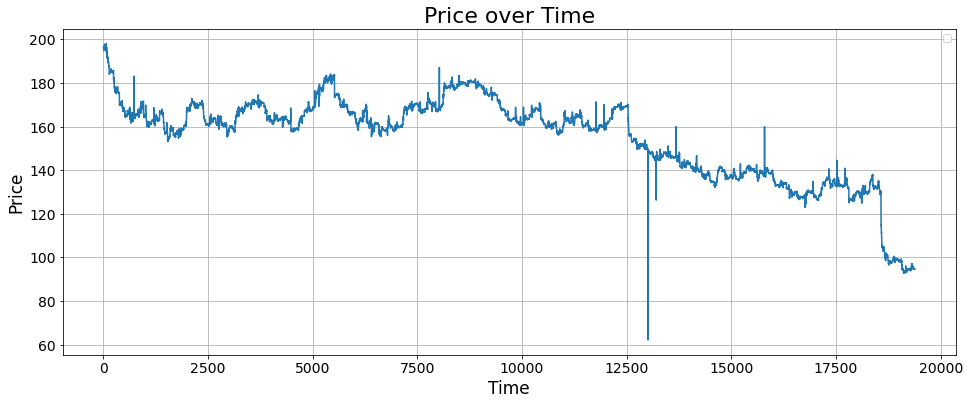

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"FIVE_MIN_BUCKET"    |"TRADED_PRICE"      |"VOLUME"  |"AVG_BID"           |"AVG_ASK"           |"MID_PRICE"         |"SUM_BID_VOL"  |"SUM_ASK_VOL"  |"RETURN"                |
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|2022-09-12 10:30:00  |170.51227497837212  |496395    |170.47042769857433  |170.49731387191673  |170.48387078524553  |24234          |22175          |0.001090584370376671    |
|2022-09-12 10:35:00  |170.7352438049027   |358149    |170.71525944076103  |170.74813923320843  |170.73169933698472  |14816          |17590          |0.0013076409106550064   |
|2022-09-12 10:40:00  |169.83332490192927  |456820    |169.84623376623378  |169.88088272629628  |169.86355824626503  |24

In [136]:

%matplotlib inline 

META_TRANSFORMED_5MIN_V3 = session.sql("""  
            
WITH traded AS (
  SELECT 
      TIME_SLICE(
        TO_TIMESTAMP_NTZ(date || LPAD(time, 9, '0'), 'YYYYMMDDHH24MISSFF3'),
        5, 'MINUTE'
      ) AS five_min_bucket,
      AVG(last_price) AS traded_price, 
      SUM(last_vol) AS volume
  FROM tick_history.public.th_sf_mktplace
  WHERE ticker = 'META'
    AND msg_type = '0'
  GROUP BY five_min_bucket
),
bidask AS (
  SELECT 
      TIME_SLICE(
        TO_TIMESTAMP_NTZ(date || LPAD(time, 9, '0'), 'YYYYMMDDHH24MISSFF3'),
        5, 'MINUTE'
      ) AS five_min_bucket,
      AVG(bid) AS avg_bid,
      AVG(ask) AS avg_ask,
      (AVG(bid) + AVG(ask)) / 2 AS mid_price,
      SUM(bid_vol) AS sum_bid_vol,
      SUM(ask_vol) AS sum_ask_vol
  FROM tick_history.public.th_sf_mktplace
  WHERE ticker = 'META'
    AND msg_type = '15'
  GROUP BY five_min_bucket
),
combined AS (
  SELECT 
    COALESCE(t.five_min_bucket, b.five_min_bucket) AS five_min_bucket,
    t.traded_price,
    t.volume,
    b.avg_bid,
    b.avg_ask,
    b.mid_price,
    b.sum_bid_vol,
    b.sum_ask_vol
  FROM traded t
  FULL OUTER JOIN bidask b 
    ON t.five_min_bucket = b.five_min_bucket
)
SELECT 
  five_min_bucket,
  traded_price,
  volume,
  avg_bid,
  avg_ask,
  mid_price,
  sum_bid_vol,
  sum_ask_vol,
  (traded_price - LAG(traded_price) OVER (ORDER BY five_min_bucket))
    / LAG(traded_price) OVER (ORDER BY five_min_bucket) AS return
FROM combined
ORDER BY five_min_bucket """)



current_price_column = META_TRANSFORMED_5MIN_V3.select('TRADED_PRICE').to_pandas()

plt.figure(figsize=(16, 6))
plt.plot(current_price_column)
plt.xlabel('Time', size=17)
plt.ylabel('Price', size=17)
plt.title('Price over Time', size=22)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

META_TRANSFORMED_5MIN_V3.show()

# Order Flow Calculation 



The *order flow* at time $t$, denoted by $OF_t$, measures the volume of buy or sell order for a trade. It is defined as:

$$
OF_t = S_i V_i
$$

Consider the average OF over a time interval where k trades take place , this calculation could reveal an Order Flow Imbalance: 

 $$
 OFI_t = \frac{1}{k} \sum_{i=1}^{k} OF_i
$$


where:

- $S_i$ is the *trade sign*, determined as:

  $$
  S_i =
  \begin{cases} 
    +1, & \text{if the trade price is above the mid-quote (buyer-initiated)},\\
    -1, & \text{if the trade price is below the mid-quote (seller-initiated)}.
  \end{cases}
  $$

- $V_i$ is the *trade volume* (the number of shares traded at time t_i )
- The sum  aggregates the order flow over a chosen time window (e.g. 30 seconds or 1 minute).


In [137]:

META_TRANSFORMED_5MIN_V3_pd = META_TRANSFORMED_5MIN_V3.to_pandas()
df = META_TRANSFORMED_5MIN_V3_pd


df["TRADE_SIGN"] = df.apply(lambda row: 1 if row["TRADED_PRICE"] > row["MID_PRICE"] 
                            else -1 if row["TRADED_PRICE"] < row["MID_PRICE"] 
                            else 0, axis=1)

df["OFI"] = df["TRADE_SIGN"] * df["VOLUME"] ###**#*#*#* THIS REALLY THE ORDER FLOW at that time  RATHER THAN THE ORDER FLOW IMBALANCE - THE OFI WILL BE COMPUTED ON A ROLLLING BASIS LATER as an average of OF values wiithin a time interval  #*#*#*#*

df = df.sort_values(by="FIVE_MIN_BUCKET")  

# df["OFI"] = df.rolling("10min", on="FIVE_MIN_BUCKET")["SIGNED_VOL"].sum()

# df["LAST_VOL_SUM_1min"] = df.rolling("10min", on="FIVE_MIN_BUCKET")["VOLUME"].sum()

df['TRADED_PRICE'] = df['TRADED_PRICE'].rolling(window=10).mean()

df_final = df


# Small Interval Analysis 

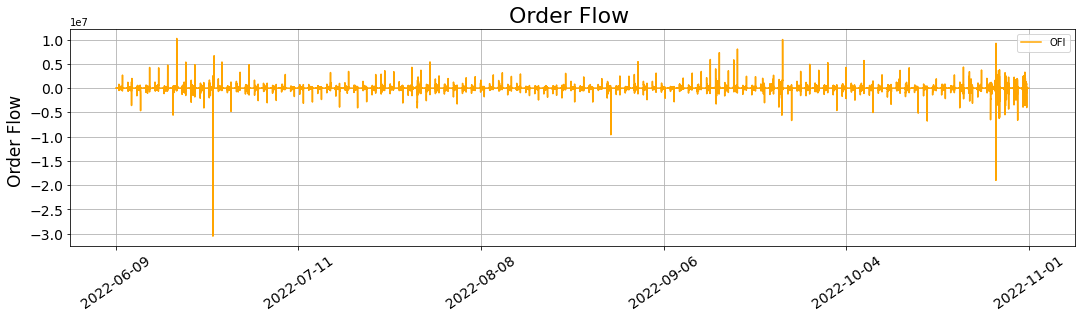

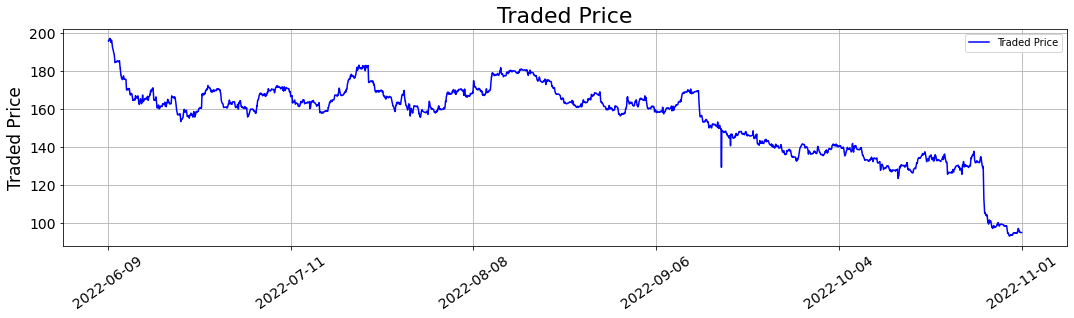

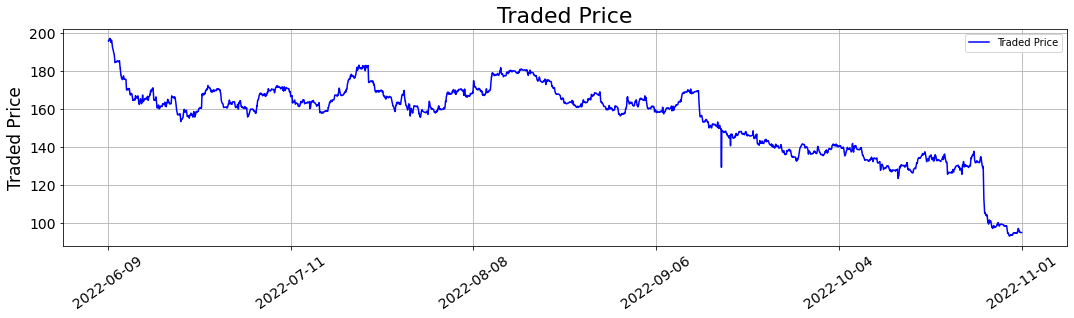

In [138]:
import numpy as np
import matplotlib.pyplot as plt

# Extract time data and prepare tick positions and labels
time = (df_final['FIVE_MIN_BUCKET'].dt.date.astype(str)).to_numpy()
num_ticks = 6
tick_positions = np.linspace(0, len(time) - 1, num_ticks, dtype=int)
tick_labels = [time[pos] for pos in tick_positions]

# Plot Order Flow Imbalance
plt.figure(figsize=(18, 4))
plt.plot(df_final['OFI'], label='OFI', color='orange')
plt.ylabel('Order Flow ', fontsize=17)
plt.title('Order Flow ', fontsize=22)
plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=35, fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# Plot Traded Price
plt.figure(figsize=(18, 4))
plt.plot(df_final['TRADED_PRICE'].to_numpy(), label='Traded Price', color='blue')
plt.ylabel('Traded Price', fontsize=17)
plt.title('Traded Price', fontsize=22)
plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=35, fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# Plot Traded Price again (if needed)
plt.figure(figsize=(18, 4))
plt.plot(df_final['TRADED_PRICE'].to_numpy(), label='Traded Price', color='blue')
plt.ylabel('Traded Price', fontsize=17)
plt.title('Traded Price', fontsize=22)
plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=35, fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.show()



Segment Interval:  2022-06-09 04:00:00 2022-11-01 19:55:00


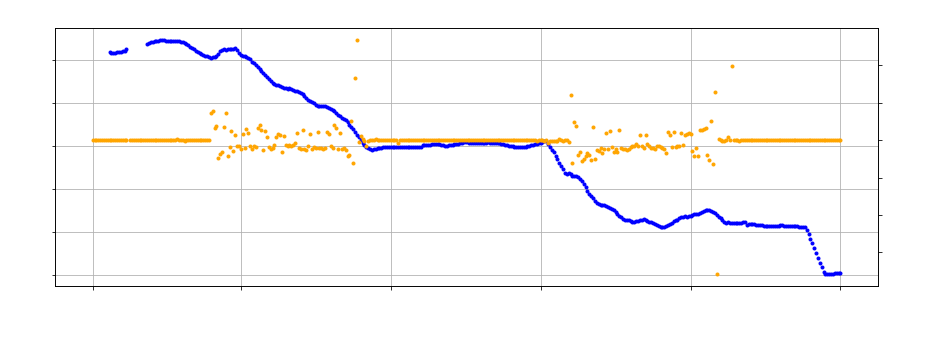

Segment Interval:  2022-06-09 04:00:00 2022-11-01 19:55:00


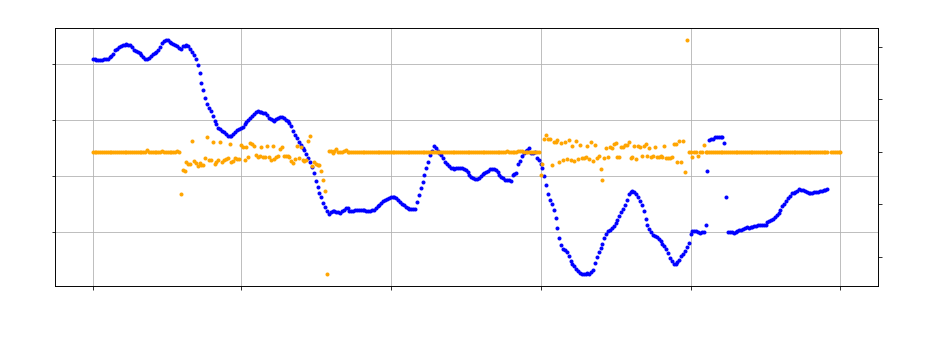

Segment Interval:  2022-06-09 04:00:00 2022-11-01 19:55:00


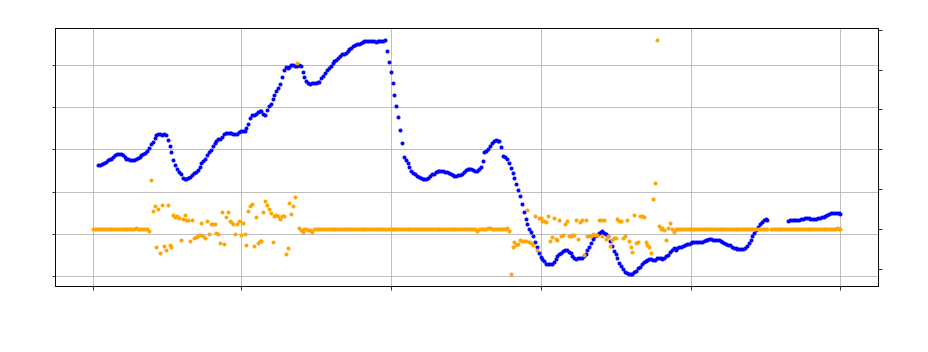

In [139]:

interval = 400 

num_plots = 3 

for i in range(num_plots):
    start_idx = i * interval
    end_idx = start_idx + interval  

    time = (df_final['FIVE_MIN_BUCKET'].astype(str)).to_numpy() #*#*#* Note  - to change to untis add "dt.date" or "dt.time" methods , 

    start_time  = time[0]
    end_time = time[-1]

    print('Segment Interval: ', start_time, end_time)
    num_ticks = 6

    time_segment = time[start_idx:end_idx]
    tick_positions = np.linspace(0, len(time_segment) - 1, num_ticks, dtype=int)  
    tick_labels = [time_segment[pos] for pos in tick_positions]  

    fig, ax1 = plt.subplots(figsize=(13, 5))

    ax1.plot(df_final['TRADED_PRICE'][start_idx:end_idx].reset_index(drop=True), '.', label='Traded Price', color='blue')
    ax1.set_ylabel('Traded Price', color='white', fontsize=17)
    ax1.tick_params(axis='y', labelcolor='white')

    ax2 = ax1.twinx()
    ofi_data = df_final['OFI'][start_idx:end_idx].reset_index(drop=True) 
    ax2.plot(ofi_data, '.', label='OF', color='orange')
    ax2.set_ylabel(' OF', color='white', fontsize=17)
    ax2.tick_params(axis='y', labelcolor='white')

    # Adjust the y-axis limits to shift the OFI lower
    ofi_min, ofi_max = ofi_data.min(), ofi_data.max()

    plt.title(f'Traded Price and Order Flow', color='white', fontsize=22)
    ax1.set_xticks(tick_positions)
    ax1.set_xticklabels(tick_labels, rotation=15, color='white', fontsize=14)
    ax1.grid(True)

    fig.tight_layout()
    plt.show()



Mean of OF values: -4396.8282423635455
Standard Deviation of OFI values: 660469.5826567595


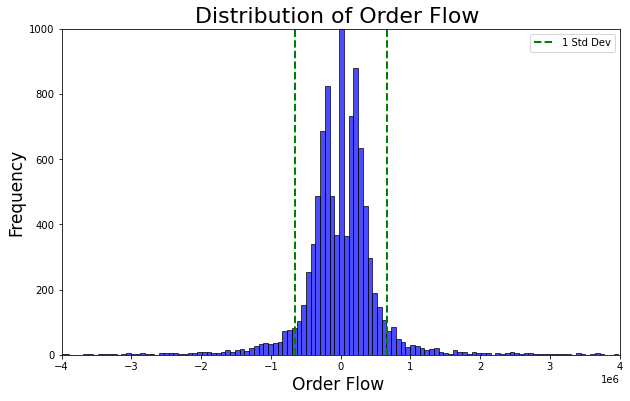

In [140]:
import matplotlib.pyplot as plt

# Calculate mean and standard deviation for the first 4000 OFI values
ofi_mean = df_final['OFI'][:4000].mean()
ofi_std = df_final['OFI'][:4000].std()

print(f"Mean of OF values: {ofi_mean}")
print(f"Standard Deviation of OFI values: {ofi_std}")

# Plot histogram of OFI values
plt.figure(figsize=(10, 6))
plt.hist(df_final['OFI'], bins=600, color='blue', alpha=0.7, edgecolor='black')

# Set labels and title with specified font sizes
plt.xlabel('Order Flow ', fontsize=17)
plt.ylabel('Frequency', fontsize=17)
plt.title('Distribution of Order Flow ', fontsize=22)

# Add vertical lines for standard deviation
plt.axvline(ofi_std, color='green', linestyle='dashed', linewidth=2)
plt.axvline(-ofi_std, color='green', linestyle='dashed', linewidth=2, label="1 Std Dev")

plt.legend()
plt.xlim(-4e6, 4e6)
plt.ylim(0, 1000)
plt.show()


# Algorithm Test - Trade Strategy




### Trade Strategy Summary  


 **Order Flow Imbalance (OFI) Rolling Mean Calculation:**  
   - The rolling mean of `OF` is computed using a window size of t , where k trades have taken place:  
 
     $$
     OFI_{(t)} = \frac{1}{k} \sum_{i=1}^{k} OFI_i
     $$  

  - The strategy identifies buy signals when `OF_ROLLING` exceeds a threshold $\sigma_{\text{OF}} \times \text{OF Sensitivity}$   
  - If `OF_ROLLING` spikes above $\sigma_{\text{OF}} \times \text{OF Sensitivity} $ a buy market order is executed.  
  - The sell order occurs after a specified time interval which we refer to as the hold period h  

  - For a set holding period h, the return for every buy/sell transaction is computed as:  

    $$ \text{Returns} = \text{Traded Price}_{t+h} - \text{Traded Price}_t $$ 

  - The percentage return for a given buy/sell segment is:  

    $$
       \text{Percentage Return} = \frac{\text{Return}}{\text{Traded Price}_t} \times 100
    $$  

**Total Return Calculation:**

 - The total return for the trading strategy is calculated by summing up the returns of all individual buy/sell segments and dividing by the buy price at the time of each buy. This approach ensures that only the buy price at the time of each buy is at risk, rather than the total amount of all buy prices summed.

- Mathematically, if there are n buy/sell segments, the total return % on the money risked can be understood as:

  $$
  R_{\text{total}} = \frac{\sum_{i=1}^{n} (\text{Traded Price}_{t_i+h} - \text{Traded Price}_{t_i})}{\max(\text{Traded Price}_{t_i})}
  $$  

 
- Alternatively, we may estimate the money risked in any given trade as the average traded(buy) price over all buy/sell segments:
 
   $$
   R_{\text{total}} = \frac{\sum_{i=1}^{n} (\text{Traded Price}_{t_i+h} - \text{Traded Price}_{t_i})}{\frac{1}{n} \sum_{i=1}^{n} \text{Traded Price}_{t_i}}
   $$  



---



# Inital Exploration - OF and Returns 


Below we instruct the algorithm to execute trades when ( OF > $\sigma_{OF}$ $\times$ OF Sensitivity )  AND ( OF < - ($\sigma_{OF}$ $\times$ OF Sensitivity) ). 

### Note -  The purpose of this is to explore the relationship between extreme positive and negative mean rolling OF values, volume, and returns. Ideally we would assume that for trades executed when the OFI is negative, the returns should be mostly negatiive (ie the sum of returns for these trades should be negative) and vic versa is the OFI is positive. This is a visual analysis. 

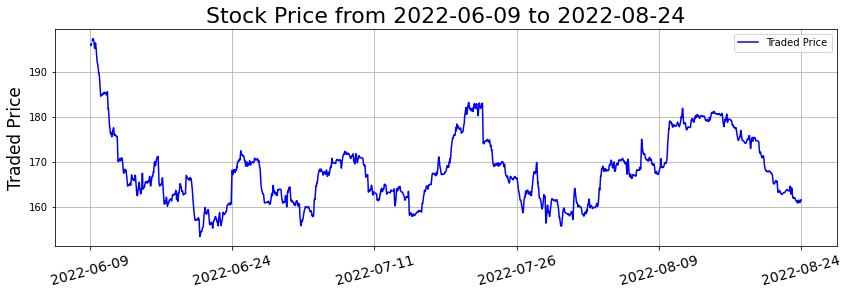

Sum of Returns: -8.112524821290293
Number of buy&sell trades executed: 204
Buy Price: 195.31182982497498, Sell Price: 192.80560705606047, Percentage Return: -1.2831904606906894%
Buy Price: 186.65949388631844, Sell Price: 184.82714847717256, Percentage Return: -0.9816513325927282%
Buy Price: 180.8607404573356, Sell Price: 176.25492440882823, Percentage Return: -2.5466090854548167%
Buy Price: 179.20528049629408, Sell Price: 176.23502637907455, Percentage Return: -1.6574590374757119%
Buy Price: 176.9926673065972, Sell Price: 175.71116374399503, Percentage Return: -0.724043307614708%
Buy Price: 176.00905457402615, Sell Price: 175.69024315413128, Percentage Return: -0.18113353353692657%
Buy Price: 170.55883452596106, Sell Price: 167.64249859296183, Percentage Return: -1.7098709316962009%
Buy Price: 169.97616904889645, Sell Price: 168.2184921153364, Percentage Return: -1.0340725664045436%
Buy Price: 165.8181851342999, Sell Price: 164.7663254434029, Percentage Return: -0.6343451956400794%
Buy

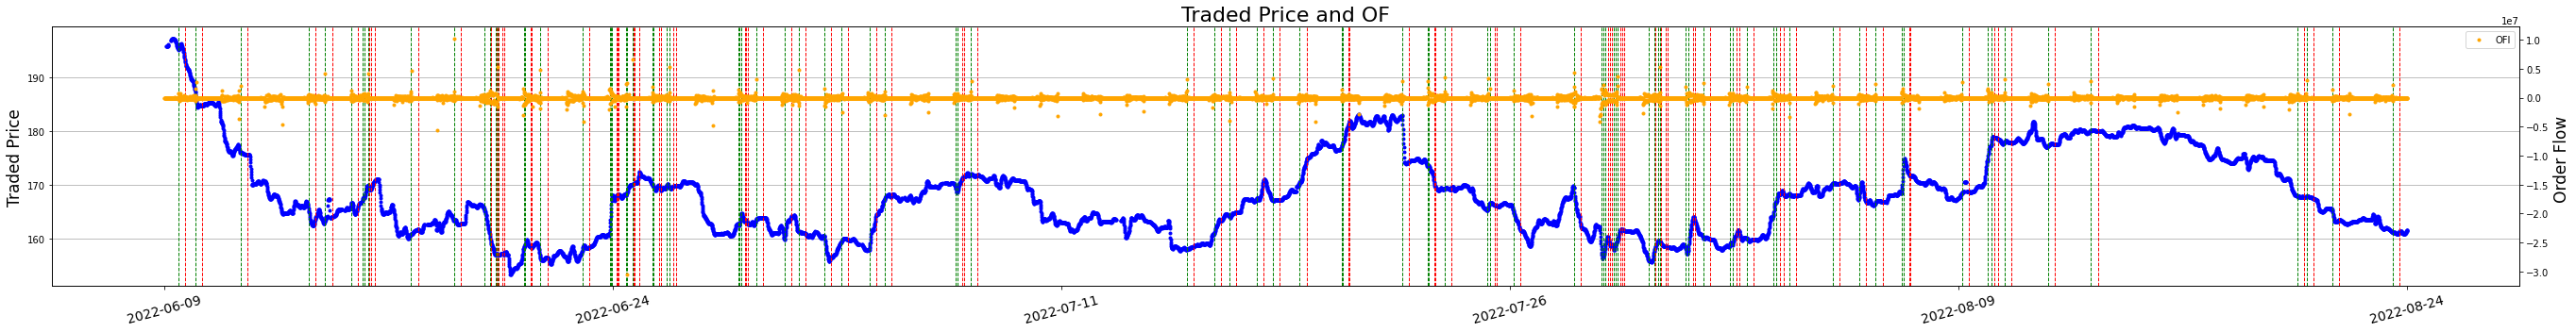

Total sum of returns: -8.112524821290293
Average Traded Price of Executed Trades: 165.9288768204223
Total number of trades executed: 204
Average Percentage Return: -4.889157919190962%


In [143]:
#*#*#*#**# Note - this is the version that includes trades that are executed at negative OFI values as well in order to the relationship between OFI vclaues and the returns 
#*#*#*#**# Note - this is the version that includes trades that are executed at negative OFI values as well in order to the relationship between OFI vclaues and the returns 
#*#*#*#**# Note - this is the version that includes trades that are executed at negative OFI values as well in order to the relationship between OFI vclaues and the returns 

start = 0
end = 10000
num_ticks = 6

time = (df_final['FIVE_MIN_BUCKET'].dt.date.astype(str)).to_numpy()
time_segment = time[start:end]
tick_positions = np.linspace(0, len(time_segment) - 1, num_ticks, dtype=int)
tick_labels = [time_segment[pos] for pos in tick_positions]

label_color = 'black'
tick_color = 'black'

plt.figure(figsize=(14, 4))
plt.plot(df_final['TRADED_PRICE'][start:end].reset_index(drop=True), color='blue', label='Traded Price')
plt.title(f"Stock Price from {time_segment[0]} to {time_segment[-1]}", color=label_color, fontsize=22)
plt.ylabel('Traded Price', color=label_color, fontsize=17)
plt.tick_params(axis='y', labelcolor=tick_color)
plt.xticks(tick_positions, tick_labels, rotation=15, color=tick_color, fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

total_sum_returns = 0
total_money_risked = 0
total_trades_executed = 0

# Define condition_window if not already defined
condition_window = 1  # Example value, adjust as needed
ofi_sensitivity = 0.75
rolling_window_mean_ofi = 3
hold_period = 30

df_test = df_final[['OFI', 'TRADED_PRICE', 'RETURN' , 'VOLUME']][start:end].reset_index(drop=True)

df_test['OFI_ROLLING'] = df_test['OFI'].rolling(window=rolling_window_mean_ofi).mean()
df_test['RETURNS_XX_IDX_AHEAD'] = 0

ofi_std = df_final['OFI'].std()

condition_test = (df_test['OFI_ROLLING'] > ofi_sensitivity * ofi_std) & df_test['OFI_ROLLING'].shift(1).rolling(window=condition_window).apply(lambda x: all(x <= ofi_sensitivity * ofi_std))
condition_test_negative = (df_test['OFI_ROLLING'] < -ofi_sensitivity * ofi_std) & df_test['OFI_ROLLING'].shift(1).rolling(window=condition_window).apply(lambda x: all(x >= -ofi_sensitivity * ofi_std))

df_test.loc[condition_test, 'RETURNS_XX_IDX_AHEAD'] = df_test['TRADED_PRICE'].shift(-hold_period) - df_test['TRADED_PRICE']
df_test.loc[condition_test_negative, 'RETURNS_XX_IDX_AHEAD'] = df_test['TRADED_PRICE'].shift(-hold_period) - df_test['TRADED_PRICE']

df_test['PERCENTAGE_RETURN'] = (df_test['RETURNS_XX_IDX_AHEAD'] / df_test['TRADED_PRICE']) * 100

non_zero_count = (df_test['RETURNS_XX_IDX_AHEAD'] != 0).sum()

print(f"Sum of Returns: {df_test['RETURNS_XX_IDX_AHEAD'].sum()}")
print(f"Number of buy&sell trades executed: {non_zero_count}")

trades = df_test[df_test['RETURNS_XX_IDX_AHEAD'] != 0].copy()
trades['SELL_PRICE'] = trades['TRADED_PRICE'] + trades['RETURNS_XX_IDX_AHEAD']

for index, row in trades.iterrows():
    print(f"Buy Price: {row['TRADED_PRICE']}, Sell Price: {row['SELL_PRICE']}, Percentage Return: {row['PERCENTAGE_RETURN']}%")

total_sum_returns += trades['RETURNS_XX_IDX_AHEAD'].sum()
total_money_risked += trades['TRADED_PRICE'].sum()

df_test['BOUGHT'] = condition_test
df_test['SOLD'] = df_test['BOUGHT'].shift(hold_period)
df_test['SOLD'] = df_test['SOLD'].fillna(False)

fig, ax1 = plt.subplots(figsize=(38, 5))
ax1.plot(df_test['TRADED_PRICE'], '.', color='blue', label='Traded Price')
ax1.set_ylabel('Traded Price', color=label_color, fontsize=17)
ax1.tick_params(axis='y', labelcolor=tick_color)
ax1.yaxis.grid(True)

ax2 = ax1.twinx()
ax2.plot(df_test['OFI'], '.', color='orange', label='OFI')
ax2.set_ylabel('Order Flow ', color=label_color, fontsize=17)
ax2.tick_params(axis='y', labelcolor=tick_color)
ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels, rotation=15, color=tick_color, fontsize=14)

condition_test_indices = df_test.index[condition_test]

for index in condition_test_indices:
    ax1.axvline(x=index, color='green', linestyle='--', linewidth=1.0)

sale_indices = df_test.index[df_test['SOLD']]

for index in sale_indices:
    ax1.axvline(x=index, color='red', linestyle='--', linewidth=1.0)

plt.title("Traded Price and OF", color=label_color, fontsize=22)

fig.tight_layout()
plt.legend()
plt.show()

total_trades_executed += non_zero_count

avg_traded_price_of_buys = total_money_risked / total_trades_executed if total_trades_executed != 0 else 0

percentage_return_avg = (total_sum_returns / avg_traded_price_of_buys) * 100 if avg_traded_price_of_buys != 0 else 0

print(f"Total sum of returns: {total_sum_returns}")
print(f"Average Traded Price of Executed Trades: {avg_traded_price_of_buys}")
print(f"Total number of trades executed: {total_trades_executed}")
print(f"Average Percentage Return: {percentage_return_avg}%")

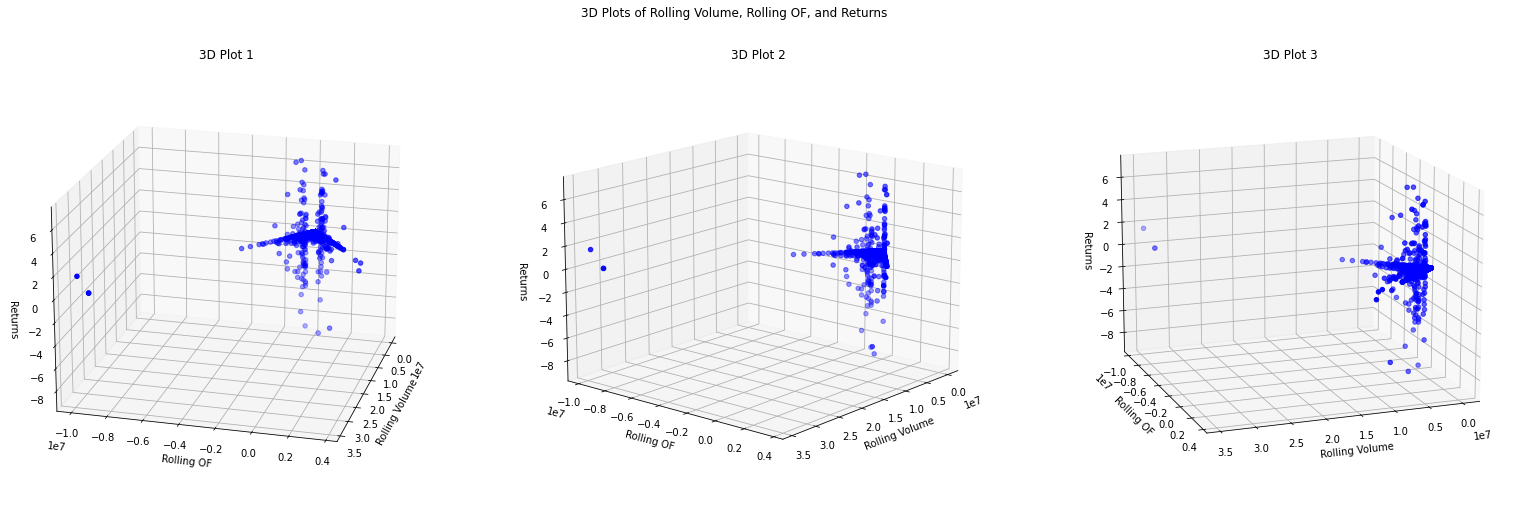

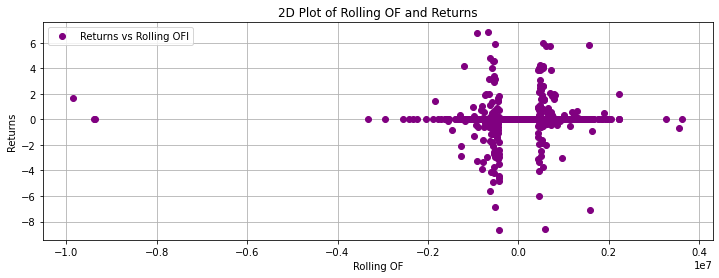

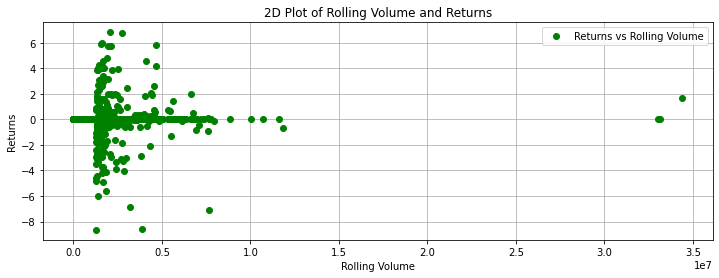

In [144]:
 # Assuming the rolling OFI uses a window of 20
df_test['ROLLING_VOLUME'] = df_test['VOLUME'].rolling(window=rolling_window_mean_ofi).sum()

# Create multiple 3D plots for the rolling OFI, rolling volume, and returns on the z-axis
fig = plt.figure(figsize=(27, 8))

# First 3D plot
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(df_test['ROLLING_VOLUME'], df_test['OFI_ROLLING'], df_test['RETURNS_XX_IDX_AHEAD'], c='b', marker='o')
ax1.set_xlabel('Rolling Volume')
ax1.set_ylabel('Rolling OF')
ax1.set_zlabel('Returns')
ax1.view_init(elev=20, azim=15)
ax1.set_title("3D Plot 1")

# Second 3D plot with a different angle
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(df_test['ROLLING_VOLUME'], df_test['OFI_ROLLING'], df_test['RETURNS_XX_IDX_AHEAD'], c='b', marker='o')
ax2.set_xlabel('Rolling Volume')
ax2.set_ylabel('Rolling OF')
ax2.set_zlabel('Returns')
ax2.view_init(elev=15, azim=40)
ax2.set_title("3D Plot 2")

# Third 3D plot with another different angle
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(df_test['ROLLING_VOLUME'], df_test['OFI_ROLLING'], df_test['RETURNS_XX_IDX_AHEAD'], c='b', marker='o')
ax3.set_xlabel('Rolling Volume')
ax3.set_ylabel('Rolling OF')
ax3.set_zlabel('Returns')
ax3.view_init(elev=15, azim=70)
ax3.set_title("3D Plot 3")

plt.suptitle("3D Plots of Rolling Volume, Rolling OF, and Returns")
plt.show()

# Create a 2D plot for the rolling OFI and returns
plt.figure(figsize=(12, 4))
plt.plot(df_test['OFI_ROLLING'].to_numpy(), df_test['RETURNS_XX_IDX_AHEAD'].to_numpy(), 'o', color='purple', label='Returns vs Rolling OFI')

# Set labels
plt.xlabel('Rolling OF')
plt.ylabel('Returns')

plt.title("2D Plot of Rolling OF and Returns")
plt.grid(True)
plt.legend()
plt.show()

# Create a 2D plot for the rolling volume and returns
plt.figure(figsize=(12, 4))
plt.plot(df_test['ROLLING_VOLUME'].to_numpy(), df_test['RETURNS_XX_IDX_AHEAD'].to_numpy(), 'o', color='green', label='Returns vs Rolling Volume')

# Set labels
plt.xlabel('Rolling Volume')
plt.ylabel('Returns')

plt.title("2D Plot of Rolling Volume and Returns")
plt.grid(True)
plt.legend()
plt.show()

# Grid Search Method  - Optimizing Parameters 


The 4 parameters that are variable are of_sensitivity, hold_period, rolling_window_mean_of, and condition_window.
 
- of_sensitivity: This variable represents the sensitivity threshold for the Order Flow rolling mean

- hold_period: This variable represents the number of periods to hold the position before selling

- rolling_window_mean_of: This variable represents the window size for calculating the rolling mean of the OF

- condition_window: This variable represents the window size where we want to execute one trade at a time - this serves to adjust the number of trades executed



In [145]:

def calculate_sum_of_percentage_returns(start, end, ofi_sensitivity, hold_period, rolling_window_mean_ofi, condition_window):
    df_test = df_final[['OFI', 'TRADED_PRICE', 'RETURN', 'VOLUME']][start:end].reset_index(drop=True)
    df_test['OFI_ROLLING'] = df_test['OFI'].rolling(window=rolling_window_mean_ofi).mean()
    df_test['RETURNS_XX_IDX_AHEAD'] = 0
    # Calculate the standard deviation of the OFI
    ofi_std = df_final['OFI'][0:4000].std()

    condition_test = (df_test['OFI_ROLLING'] > ofi_sensitivity*ofi_std) & df_test['OFI_ROLLING'].shift(1).rolling(window=condition_window).apply(lambda x: all(x <= ofi_sensitivity*ofi_std))
    df_test.loc[condition_test, 'RETURNS_XX_IDX_AHEAD'] = df_test['TRADED_PRICE'].shift(-hold_period) - df_test['TRADED_PRICE']
    
    # Calculate total returns
    total_returns = df_test['RETURNS_XX_IDX_AHEAD'].sum()

    max_buy_price = df_test.loc[condition_test, 'TRADED_PRICE'].max()
    
    # Calculate average traded price of the buys
    avg_traded_price_of_buys = df_test.loc[condition_test, 'TRADED_PRICE'].mean() if condition_test.any() else 0
    
    non_zero_count = (df_test['RETURNS_XX_IDX_AHEAD'] != 0).sum()

    percentage_return_avg = (total_returns / avg_traded_price_of_buys) * 100 if avg_traded_price_of_buys != 0 else 0

    return_relative_to_max_buy_price = (total_returns / max_buy_price) * 100


    
    return total_returns, avg_traded_price_of_buys, non_zero_count, percentage_return_avg , max_buy_price , return_relative_to_max_buy_price


In [146]:

from sklearn.model_selection import ParameterGrid
import numpy as np

def grid_search_ofi_parameters(start, end, ofi_sensitivity_interval, hold_period_interval, rolling_window_mean_ofi_interval, condition_window_interval, num_points_ofi, num_points_hold, num_points_rolling, num_points_condition):
    # Create the parameter grid using linspace with different number of points for each parameter
    param_grid = {
        'ofi_sensitivity': np.linspace(ofi_sensitivity_interval[0], ofi_sensitivity_interval[1], num_points_ofi),
        'hold_period': np.linspace(hold_period_interval[0], hold_period_interval[1], num_points_hold, dtype=int),
        'rolling_window_mean_ofi': np.linspace(rolling_window_mean_ofi_interval[0], rolling_window_mean_ofi_interval[1], num_points_rolling, dtype=int),
        'condition_window': np.linspace(condition_window_interval[0], condition_window_interval[1], num_points_condition, dtype=int)
    }
    
    results = []
    
    for params in ParameterGrid(param_grid):
        ofi_sensitivity = params['ofi_sensitivity']
        hold_period = params['hold_period']
        rolling_window_mean_ofi = params['rolling_window_mean_ofi']
        condition_window = params['condition_window']
        
        sum_returns, avg_traded_price_of_buys, non_zero_count, percentage_return_avg, max_buy_price, return_relative_to_max_buy_price = calculate_sum_of_percentage_returns(start, end, ofi_sensitivity, hold_period, rolling_window_mean_ofi, condition_window)
        
        results.append((params, sum_returns, percentage_return_avg, avg_traded_price_of_buys, non_zero_count, max_buy_price, return_relative_to_max_buy_price))
    
    # Sort results by return_relative_to_max_buy_price in descending order and get the top 5
    top_results = sorted(results, key=lambda x: x[6], reverse=True)[:5]
    
    return top_results

# Example usage with interval sizes and different number of points for each parameter
ofi_sensitivity_interval = (0, 2)
hold_period_interval = (10, 60)
rolling_window_mean_ofi_interval = (3, 50)
condition_window_interval = (1, 60)
num_points_ofi = 9
num_points_hold = 4
num_points_rolling = 3
num_points_condition = 3

top_params = grid_search_ofi_parameters(
    start=4000, 
    end=8000, 
    ofi_sensitivity_interval=ofi_sensitivity_interval, 
    hold_period_interval=hold_period_interval, 
    rolling_window_mean_ofi_interval=rolling_window_mean_ofi_interval, 
    condition_window_interval=condition_window_interval,
    num_points_ofi=num_points_ofi,
    num_points_hold=num_points_hold,
    num_points_rolling=num_points_rolling,
    num_points_condition=num_points_condition
)

for i, (params, sum_returns, percentage_return_avg, avg_traded_price_of_buys, total_trades, max_buy_price, return_relative_to_max_buy_price) in enumerate(top_params, start=1):
    print(f"Top {i} Parameters: {params}")
    print(f"Sum of Returns: {sum_returns}")
    print(f"Percentage Average Returns: {percentage_return_avg}")
    print(f"Average Traded Price of Buys: {avg_traded_price_of_buys}")
    print(f"Total Trades: {total_trades}")
    print(f"Max Buy Price: {max_buy_price}")
    print(f"Returns relative to max buy price: {return_relative_to_max_buy_price}%\n")


Top 1 Parameters: {'condition_window': 1, 'hold_period': 10, 'ofi_sensitivity': 0.0, 'rolling_window_mean_ofi': 3}
Sum of Returns: 41.304585204339816
Percentage Average Returns: 24.855426334528307
Average Traded Price of Buys: 166.17934711085965
Total Trades: 462
Max Buy Price: 182.98901605753517
Returns relative to max buy price: 22.57216640333914%

Top 2 Parameters: {'condition_window': 1, 'hold_period': 10, 'ofi_sensitivity': 0.25, 'rolling_window_mean_ofi': 3}
Sum of Returns: 34.473997705302054
Percentage Average Returns: 20.661455523550767
Average Traded Price of Buys: 166.85173832989253
Total Trades: 156
Max Buy Price: 182.8880028271446
Returns relative to max buy price: 18.849786302213015%

Top 3 Parameters: {'condition_window': 1, 'hold_period': 10, 'ofi_sensitivity': 0.5, 'rolling_window_mean_ofi': 50}
Sum of Returns: 0
Percentage Average Returns: 0
Average Traded Price of Buys: 0
Total Trades: 0
Max Buy Price: nan
Returns relative to max buy price: nan%

Top 4 Parameters: {'c

In [147]:
def create_intervals(start, end, interval_size):
    return [(i, min(i + interval_size, end)) for i in range(start, end, interval_size)]


def analyze_intervals(start, end, ofi_sensitivity, hold_period, interval_size, rolling_window_mean_ofi, condition_window, num_ticks):
    intervals = create_intervals(start, end, interval_size)
    time = (df_final['FIVE_MIN_BUCKET'].dt.date.astype(str)).to_numpy()
    time_segment = time[start:end]
    tick_positions = np.linspace(0, len(time_segment) - 1, num_ticks, dtype=int)
    tick_labels = [time_segment[pos] for pos in tick_positions]

    label_color = 'black'
    tick_color = 'black'

    plt.figure(figsize=(14, 4))
    plt.plot(df_final['TRADED_PRICE'][start:end].reset_index(drop=True), color='blue', label='Traded Price')
    plt.title(f"Stock Price from {time_segment[0]} to {time_segment[-1]}", color=label_color, size=22)
    plt.ylabel('Traded Price', color=label_color, size=17)
    plt.tick_params(axis='y', labelcolor=tick_color)
    plt.xticks(tick_positions, tick_labels, rotation=15, color=tick_color, fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(True)
    plt.legend()
    plt.show()

    total_sum_returns = 0
    total_money_risked = 0
    total_trades_executed = 0

    for interval_start, interval_end in intervals:
        time = (df_final['FIVE_MIN_BUCKET'].astype(str)).to_numpy()
        time_segment = time[interval_start:interval_end]
        tick_positions = np.linspace(0, len(time_segment) - 1, num_ticks, dtype=int)
        tick_labels = [time_segment[pos] for pos in tick_positions]

        df_test = df_final[['OFI', 'TRADED_PRICE', 'RETURN']][interval_start:interval_end].reset_index(drop=True)

        df_test['OFI_ROLLING'] = df_test['OFI'].rolling(window=rolling_window_mean_ofi).mean()
        df_test['RETURNS_XX_IDX_AHEAD'] = 0

        ofi_std = df_final['OFI'].std()

        condition_test = (df_test['OFI_ROLLING'] > ofi_sensitivity * ofi_std) & df_test['OFI_ROLLING'].shift(1).rolling(window=condition_window).apply(lambda x: all(x <= ofi_sensitivity * ofi_std))

        df_test.loc[condition_test, 'RETURNS_XX_IDX_AHEAD'] = df_test['TRADED_PRICE'].shift(-hold_period) - df_test['TRADED_PRICE']
        df_test['PERCENTAGE_RETURN'] = (df_test['RETURNS_XX_IDX_AHEAD'] / df_test['TRADED_PRICE'].replace(0, np.nan)) * 100

        non_zero_count = (df_test['RETURNS_XX_IDX_AHEAD'] != 0).sum()

        print(f"Sum of Returns: {df_test['RETURNS_XX_IDX_AHEAD'].sum()}")
        print(f"Number of buy&sell trades executed: {non_zero_count}")

        trades = df_test[df_test['RETURNS_XX_IDX_AHEAD'] != 0].copy()
        trades['SELL_PRICE'] = trades['TRADED_PRICE'] + trades['RETURNS_XX_IDX_AHEAD']

        for index, row in trades.iterrows():
            print(f"Buy Price: {row['TRADED_PRICE']}, Sell Price: {row['SELL_PRICE']}, Percentage Return: {row['PERCENTAGE_RETURN']}%")

        total_sum_returns += trades['RETURNS_XX_IDX_AHEAD'].sum()
        total_money_risked += trades['TRADED_PRICE'].sum()

        df_test['BOUGHT'] = condition_test
        df_test['SOLD'] = df_test['BOUGHT'].shift(hold_period)
        df_test['SOLD'] = df_test['SOLD'].fillna(False)

        fig, ax1 = plt.subplots(figsize=(35, 5))
        ax1.plot(df_test['TRADED_PRICE'], '.', color='blue', label='Traded Price')
        ax1.set_ylabel('Traded Price', color=label_color, size=17)
        ax1.tick_params(axis='y', labelcolor=tick_color)
        ax1.yaxis.grid(True)

        ax2 = ax1.twinx()
        ax2.plot(df_test['OFI'], '.', color='orange', label='OF')
        ax2.set_ylabel('Order Flow ', color=label_color, size=17)
        ax2.tick_params(axis='y', labelcolor=tick_color)
        ax1.set_xticks(tick_positions)
        ax1.set_xticklabels(tick_labels, rotation=15, color=tick_color, fontsize=14)
        plt.yticks(fontsize=14)

        condition_test_indices = df_test.index[condition_test]

        for index in condition_test_indices:
            ax1.axvline(x=index, color='green', linestyle='--', linewidth=1.0)

        sale_indices = df_test.index[df_test['SOLD']]

        for index in sale_indices:
            ax1.axvline(x=index, color='red', linestyle='--', linewidth=1.0)

        plt.title("Traded Price and OF", color=label_color, size=22)

        fig.tight_layout()
        plt.legend()
        plt.show()

        total_trades_executed += non_zero_count

    avg_traded_price_of_buys = total_money_risked / total_trades_executed if total_trades_executed != 0 else 0

    percentage_return_avg = (total_sum_returns / avg_traded_price_of_buys) * 100 if avg_traded_price_of_buys != 0 else 0

    max_buy_price = trades['TRADED_PRICE'].max() if not trades.empty else 1  # Avoid division by zero
    print(f"Total sum of returns across all intervals: {total_sum_returns}")
    print(f"Average Traded Price of Executed Trades: {avg_traded_price_of_buys}")
    print(f"Total number of trades executed across all intervals: {total_trades_executed}")
    print(f"Average Percentage Return: {percentage_return_avg}%")
    print(f"Returns relative to max buy price: {total_sum_returns / max_buy_price * 100}%")

---
# **Strategy Demo** 
--- 

## - ***Green line*** : reresents that a trade is executed
## - ***Red line*** : represents that the sell has a been executed

## In short: 

## The algorithm 'waits' for a buy signal (based on the OFI) , then executes a trade and sells it after the defined hold period. This is what happens whenever there is a buy signal and the hold period is held constant for simplicity. 

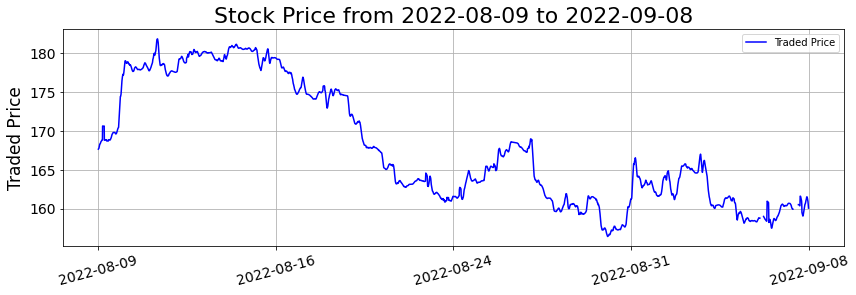

Sum of Returns: 18.732590234526555
Number of buy&sell trades executed: 137
Buy Price: 168.43488298969547, Sell Price: 168.82707493968732, Percentage Return: 0.23284484961220772%
Buy Price: 174.6281879947964, Sell Price: 177.1465803036923, Percentage Return: 1.4421453591277837%
Buy Price: 177.24437772602306, Sell Price: 178.94735778572564, Percentage Return: 0.9608090713799554%
Buy Price: 178.15946399788646, Sell Price: 178.8399596475227, Percentage Return: 0.381958743232588%
Buy Price: 179.05419737724952, Sell Price: 178.76706382308456, Percentage Return: -0.16036125283341168%
Buy Price: 178.90512688289368, Sell Price: 178.48290371959456, Percentage Return: -0.23600394838069563%
Buy Price: 178.65126031016806, Sell Price: 178.36959309552955, Percentage Return: -0.15766315566399158%
Buy Price: 178.46133785396734, Sell Price: 178.09964908770854, Percentage Return: -0.20267065719005176%
Buy Price: 177.93638139975099, Sell Price: 177.72354142409105, Percentage Return: -0.11961577165142354%


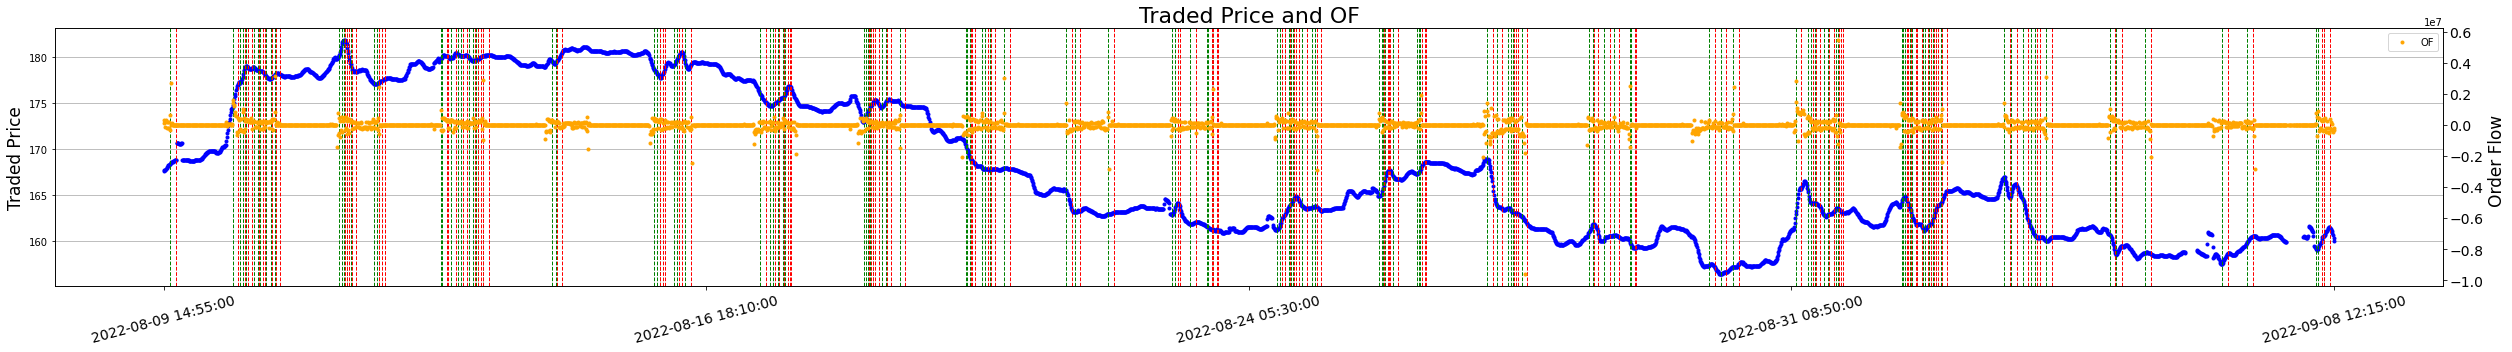

Total sum of returns across all intervals: 18.732590234526555
Average Traded Price of Executed Trades: 168.69252272979963
Total number of trades executed across all intervals: 137
Average Percentage Return: 11.104576498942494%
Returns relative to max buy price: 10.300815835162327%


In [148]:

analyze_intervals(start = 8000, end = 12000, ofi_sensitivity = 0.25, hold_period = 10, interval_size = 5000, rolling_window_mean_ofi = 3, condition_window = 1, num_ticks = 5) # Top 2 Parameters: {'condition_window': 1, 'hold_period': 10, 'ofi_sensitivity': 0.25, 'rolling_window_mean_ofi': 3}


In [149]:
total_returns = []
ofi_sensitivity_values = np.linspace(0, 3, 200)

for ofi_sensitivity in ofi_sensitivity_values:
    total_return , _ , _ , _ ,_,_= calculate_sum_of_percentage_returns(start = 0, end = 10000, ofi_sensitivity = ofi_sensitivity, hold_period = 30, rolling_window_mean_ofi = 3, condition_window=1)
    total_returns.append(total_return)



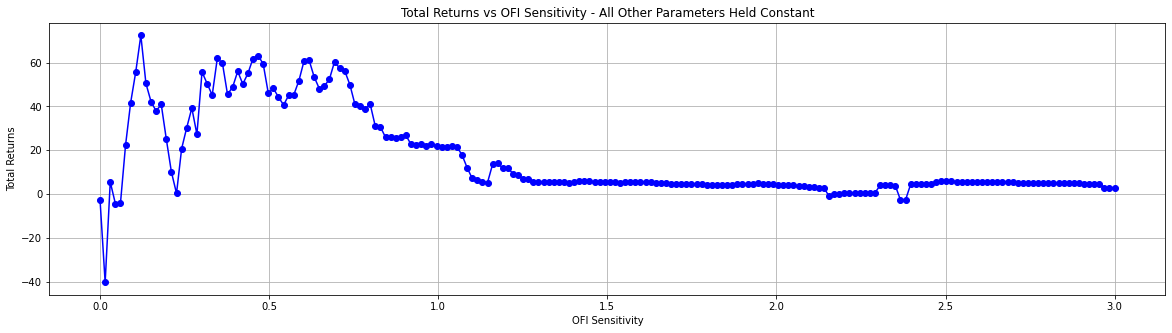

In [150]:

plt.figure(figsize=(20, 5))
plt.plot(ofi_sensitivity_values, total_returns,'-o', color='blue')
plt.title('Total Returns vs OFI Sensitivity - All Other Parameters Held Constant')
plt.xlabel('OFI Sensitivity')
plt.ylabel('Total Returns')
plt.grid(True)
plt.show()


----

<h1 style='text-align: center;'>Case 2 - IBM</h1>

---

# Data Ingestion, Transformations & Engineering 
  


No handles with labels found to put in legend.


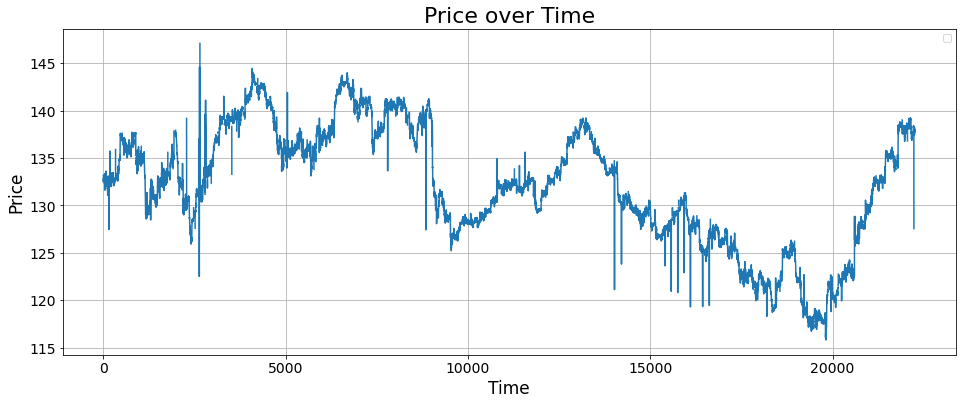

----------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"FIVE_MIN_BUCKET"    |"TRADED_PRICE"      |"VOLUME"  |"AVG_BID"  |"AVG_ASK"           |"MID_PRICE"         |"SUM_BID_VOL"  |"SUM_ASK_VOL"  |"RETURN"                |
----------------------------------------------------------------------------------------------------------------------------------------------------------------------
|2022-09-19 17:20:00  |127.57              |2         |NULL       |NULL                |NULL                |NULL           |NULL           |-0.0018257218121593148  |
|2022-09-19 17:25:00  |127.43919999999999  |4         |NULL       |NULL                |NULL                |NULL           |NULL           |-0.0010253194324685098  |
|2022-09-19 17:30:00  |128.0               |20        |127.585    |128.0               |127.79249999999999  |2              |22             |0.004400529821279596    

In [151]:

%matplotlib inline 

IBM = session.sql("""  
            
WITH traded AS (
  SELECT 
      TIME_SLICE(
        TO_TIMESTAMP_NTZ(date || LPAD(time, 9, '0'), 'YYYYMMDDHH24MISSFF3'),
        5, 'MINUTE'
      ) AS five_min_bucket,
      AVG(last_price) AS traded_price, 
      SUM(last_vol) AS volume
  FROM tick_history.public.th_sf_mktplace
  WHERE ticker = 'IBM'
    AND msg_type = '0'
  GROUP BY five_min_bucket
),
bidask AS (
  SELECT 
      TIME_SLICE(
        TO_TIMESTAMP_NTZ(date || LPAD(time, 9, '0'), 'YYYYMMDDHH24MISSFF3'),
        5, 'MINUTE'
      ) AS five_min_bucket,
      AVG(bid) AS avg_bid,
      AVG(ask) AS avg_ask,
      (AVG(bid) + AVG(ask)) / 2 AS mid_price,
      SUM(bid_vol) AS sum_bid_vol,
      SUM(ask_vol) AS sum_ask_vol
  FROM tick_history.public.th_sf_mktplace
  WHERE ticker = 'IBM'
    AND msg_type = '15'
  GROUP BY five_min_bucket
),
combined AS (
  SELECT 
    COALESCE(t.five_min_bucket, b.five_min_bucket) AS five_min_bucket,
    t.traded_price,
    t.volume,
    b.avg_bid,
    b.avg_ask,
    b.mid_price,
    b.sum_bid_vol,
    b.sum_ask_vol
  FROM traded t
  FULL OUTER JOIN bidask b 
    ON t.five_min_bucket = b.five_min_bucket
)
SELECT 
  five_min_bucket,
  traded_price,
  volume,
  avg_bid,
  avg_ask,
  mid_price,
  sum_bid_vol,
  sum_ask_vol,
  (traded_price - LAG(traded_price) OVER (ORDER BY five_min_bucket))
    / LAG(traded_price) OVER (ORDER BY five_min_bucket) AS return
FROM combined
ORDER BY five_min_bucket """)



current_price_column = IBM.select('TRADED_PRICE').to_pandas()


plt.figure(figsize=(16, 6))
plt.plot(current_price_column)
plt.xlabel('Time', size=17)
plt.ylabel('Price', size=17)
plt.title('Price over Time', size=22)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

IBM.show()

# Order Flow Calculation 



The *order flow* at time $t$, denoted by $OF_t$, measures the net volume of aggressive buy vs. sell orders within a chosen time window. It is defined as:

$$
OF_t = S_i V_i
$$

Consider the average OF over a time interval k: 

 $$
 OF_t = \frac{1}{k} \sum_{i=1}^{k} OFI_i
$$


where:

- $S_i$ is the *trade sign*, determined as:

  $$
  S_i =
  \begin{cases} 
    +1, & \text{if the trade price is above the mid-quote (buyer-initiated)},\\
    -1, & \text{if the trade price is below the mid-quote (seller-initiated)}.
  \end{cases}
  $$

- $V_i$ is the *trade volume* (the number of shares traded at time t_i )
- The sum  aggregates the order flow over a chosen time window (e.g. 30 seconds or 1 minute).


In [152]:

IBM_pd = IBM.to_pandas()
df = IBM_pd

df = df.dropna(subset=['TRADED_PRICE']).copy()


df["TRADE_SIGN"] = df.apply(lambda row: 1 if row["TRADED_PRICE"] > row["MID_PRICE"] 
                            else -1 if row["TRADED_PRICE"] < row["MID_PRICE"] 
                            else 0, axis=1)

df["OFI"] = df["TRADE_SIGN"] * df["VOLUME"] ###NOTEEEE**#*#*#*#**# THIS REALLY THE ORDER FLOW at that time  RATHER THAN THE ORDER FLOW IMBALANCE - THE OFI WILL BE COMPUTED as an average ON A ROLLLING BASIS LATER *#*#*#*#*#*

df = df.sort_values(by="FIVE_MIN_BUCKET")  

# df["OFI"] = df.rolling("10min", on="FIVE_MIN_BUCKET")["SIGNED_VOL"].sum()

# df["LAST_VOL_SUM_1min"] = df.rolling("10min", on="FIVE_MIN_BUCKET")["VOLUME"].sum()

df['TRADED_PRICE'] = df['TRADED_PRICE'].rolling(window=10).mean()

df_final = df



# Small Interval Analysis 

No handles with labels found to put in legend.


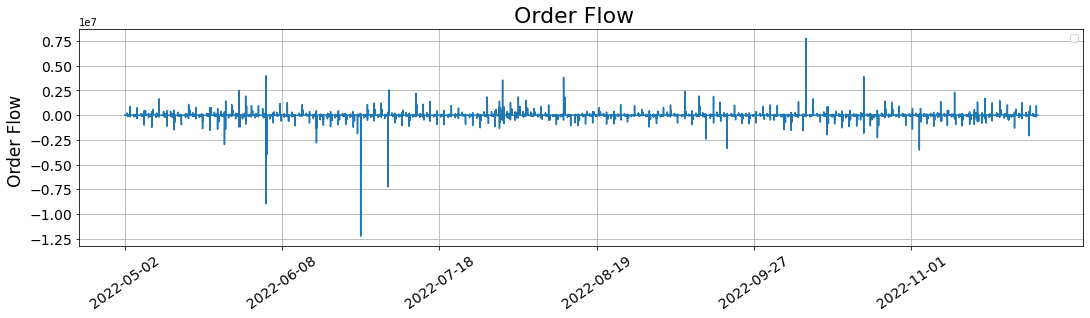

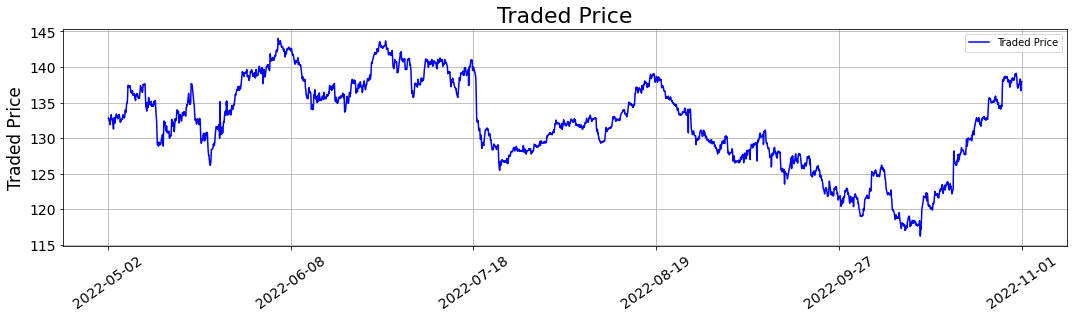

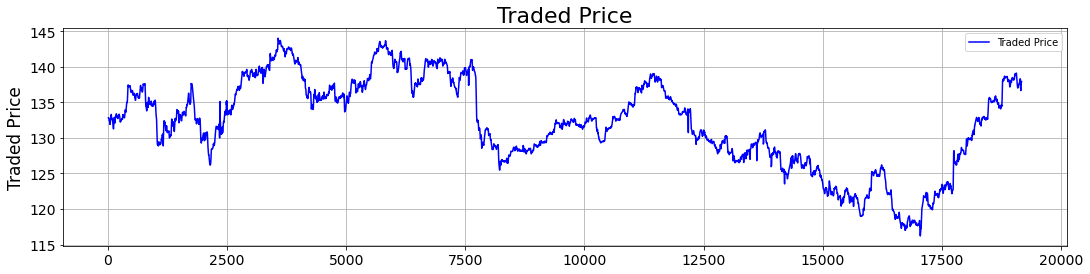

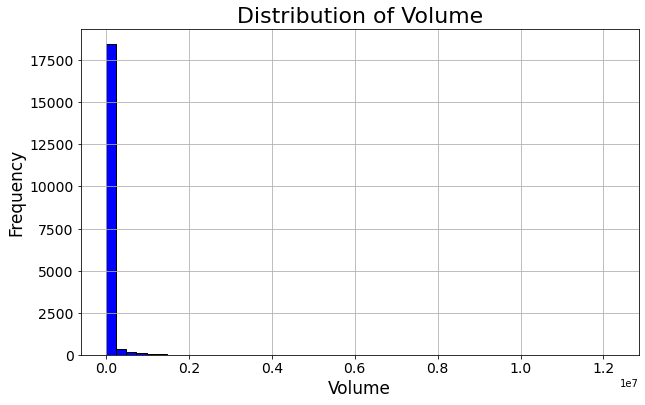

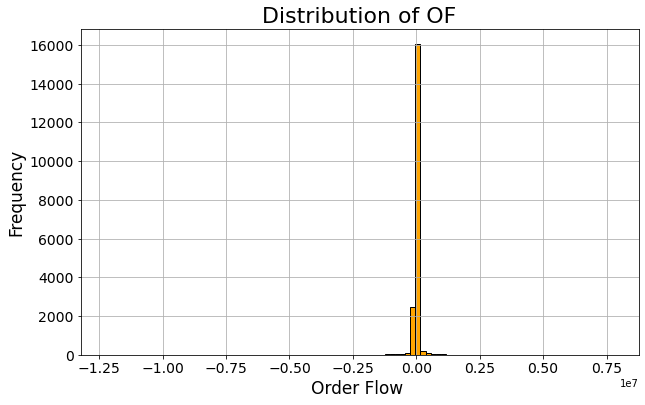

In [153]:
import numpy as np 

time = (df_final['FIVE_MIN_BUCKET'].dt.date.astype(str)).to_numpy()
num_ticks = 6
tick_positions = np.linspace(0, len(time) - 1, num_ticks, dtype=int)  
tick_labels = [time[pos] for pos in tick_positions]  

plt.figure(figsize=(18, 4))
plt.plot(df_final['OFI'])
plt.ylabel('Order Flow ', size=17)
plt.title('Order Flow  ', fontsize=22)
plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=35, fontsize=14)
plt.yticks(fontsize=14)

plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(18, 4))
plt.plot(df_final['TRADED_PRICE'].to_numpy(), label='Traded Price', color='blue')
plt.ylabel('Traded Price', size=17)
plt.title('Traded Price', fontsize=22)
plt.legend()
plt.grid(True)

plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=35, fontsize=14)
plt.yticks(fontsize=14)
plt.show()


plt.figure(figsize=(18, 4))
plt.plot(df_final['TRADED_PRICE'].to_numpy(), label='Traded Price', color='blue')
plt.ylabel('Traded Price', size=17)
plt.title('Traded Price', fontsize=22)
plt.legend()
plt.grid(True)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()




df_final['OFI'].max()


plt.figure(figsize=(10, 6))
plt.hist(df_final['VOLUME'], bins=50, color='blue', edgecolor='black')
plt.xlabel('Volume', size=17)
plt.ylabel('Frequency', size=17)
plt.title('Distribution of Volume', fontsize=22)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df_final['OFI'], bins=100, color='orange', edgecolor='black')
plt.xlabel('Order Flow ', size=17)
plt.ylabel('Frequency', size=17)
plt.title('Distribution of OF', fontsize=22)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.show()


Segment Interval:  2022-05-02 04:00:00 2022-11-01 19:55:00


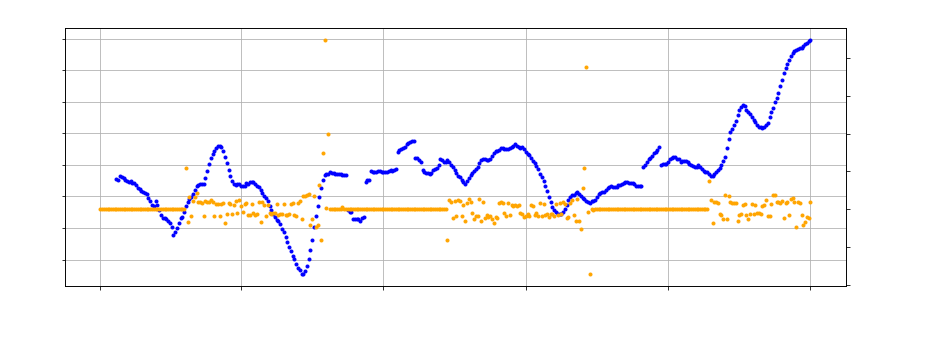

Segment Interval:  2022-05-02 04:00:00 2022-11-01 19:55:00


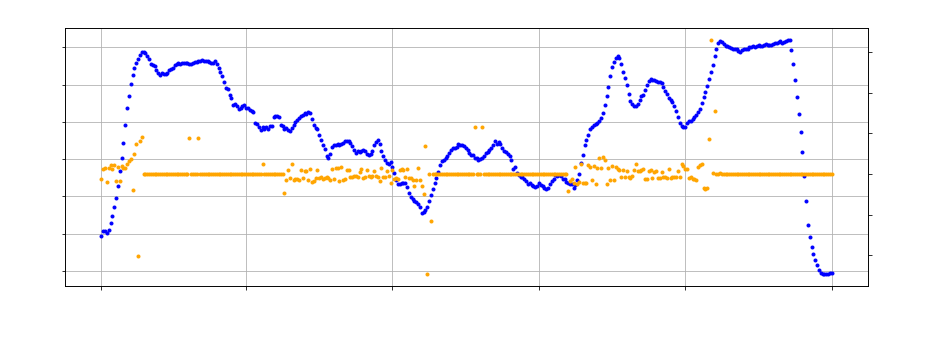

Segment Interval:  2022-05-02 04:00:00 2022-11-01 19:55:00


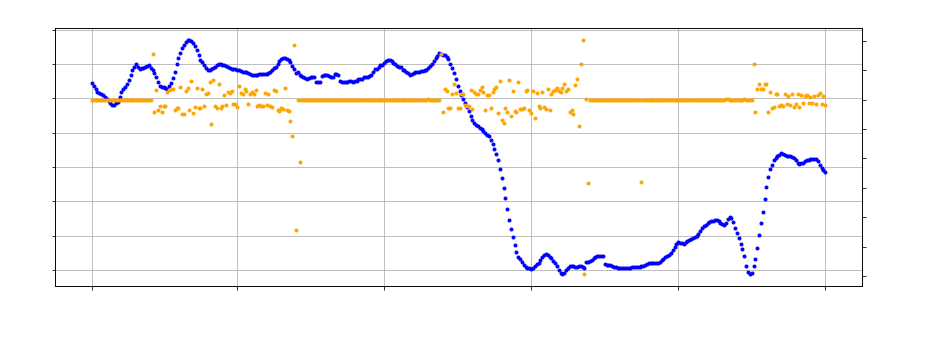

In [154]:

interval = 400 

num_plots = 3 

for i in range(num_plots):
    start_idx = i * interval
    end_idx = start_idx + interval  

    time = (df_final['FIVE_MIN_BUCKET'].astype(str)).to_numpy() #*#*#* Note  - to change to untis add "dt.date" or "dt.time" methods , 

    start_time  = time[0]
    end_time = time[-1]

    print('Segment Interval: ', start_time, end_time)
    num_ticks = 6

    time_segment = time[start_idx:end_idx]
    tick_positions = np.linspace(0, len(time_segment) - 1, num_ticks, dtype=int)  
    tick_labels = [time_segment[pos] for pos in tick_positions]  

    fig, ax1 = plt.subplots(figsize=(13, 5))

    ax1.plot(df_final['TRADED_PRICE'][start_idx:end_idx].reset_index(drop=True), '.', label='Traded Price', color='blue')
    ax1.set_ylabel('Traded Price', color='white', size=17)
    ax1.tick_params(axis='y', labelcolor='white')

    ax2 = ax1.twinx()
    ofi_data = df_final['OFI'][start_idx:end_idx].reset_index(drop=True) 
    ax2.plot(ofi_data, '.', label='OFI', color='orange')
    ax2.set_ylabel('OF', color='white', size=17)
    ax2.tick_params(axis='y', labelcolor='white')

    # Adjust the y-axis limits to shift the OFI lower
    ofi_min, ofi_max = ofi_data.min(), ofi_data.max()

    plt.title(f'Traded Price and OF', color='white', size=22)
    ax1.set_xticks(tick_positions)
    ax1.set_xticklabels(tick_labels, rotation=15, color='white', fontsize=14)
    ax1.grid(True)

    fig.tight_layout()
    plt.show()



Mean of OFI values: -2303.72
Standard Deviation of OFI values: 230491.71507946745


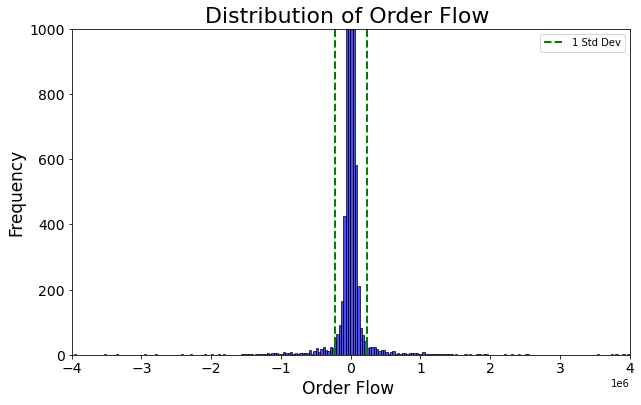

In [155]:

import matplotlib.pyplot as plt

ofi_mean = df_final['OFI'][0:4000].mean()
ofi_std = df_final['OFI'][0:4000].std()

print(f"Mean of OFI values: {ofi_mean}")
print(f"Standard Deviation of OFI values: {ofi_std}")

plt.figure(figsize=(10, 6))
plt.hist(df_final['OFI'], bins=600, color='blue', alpha=0.7, edgecolor='black')

plt.xlabel('Order Flow ', fontsize=17)
plt.ylabel('Frequency', fontsize=17)
plt.title('Distribution of Order Flow ', fontsize=22)

plt.axvline(ofi_std, color='green', linestyle='dashed', linewidth=2)
plt.axvline(-ofi_std, color='green', linestyle='dashed', linewidth=2, label="1 Std Dev")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend()
plt.xlim(-4e6, 4e6)
plt.ylim(0, 1000)
plt.show()


# Algorithm Test - Trade Strategy


### Trade Strategy Summary  


 **Order Flow Imbalance (OFI) Rolling Mean Calculation:**  
   - The rolling mean of `OF` is computed using a window size of k:  
 
     $$
     OF_{\text{rolling}}(t) = \frac{1}{k} \sum_{i=t-k}^{t} OFI_i
     $$  

  - The strategy identifies buy signals when `OF_ROLLING` exceeds a threshold $\sigma_{\text{OF}} \times \text{OF Sensitivity}$   
  - If `OF_ROLLING` spikes above $\sigma_{\text{OF}} \times \text{OF Sensitivity} $ a buy market order is executed.  
  - The sell order occurs after a specified time interval which we refer to as the hold period h  

  - For a set holding period h, the return for every buy/sell transaction is computed as:  

    $$ \text{Returns} = \text{Traded Price}_{t+h} - \text{Traded Price}_t $$ 

  - The percentage return for a given buy/sell segment is:  

    $$
       \text{Percentage Return} = \frac{\text{Return}}{\text{Traded Price}_t} \times 100
    $$  

**Total Return Calculation:**

 - The total return for the trading strategy is calculated by summing up the returns of all individual buy/sell segments and dividing by the buy price at the time of each buy. This approach ensures that only the buy price at the time of each buy is at risk, rather than the total amount of all buy prices summed.

- Mathematically, if there are n buy/sell segments, the total return % on the money risked can be understood as:

  $$
  R_{\text{total}} = \frac{\sum_{i=1}^{n} (\text{Traded Price}_{t_i+h} - \text{Traded Price}_{t_i})}{\max(\text{Traded Price}_{t_i})}
  $$  

 
- Alternatively, we may estimate the money risked in any given trade as the average traded(buy) price over all buy/sell segments:
 
   $$
   R_{\text{total}} = \frac{\sum_{i=1}^{n} (\text{Traded Price}_{t_i+h} - \text{Traded Price}_{t_i})}{\frac{1}{n} \sum_{i=1}^{n} \text{Traded Price}_{t_i}}
   $$  


---




# Inital Exploration - OF and Returns 


Below we instruct the algorithm to execute trades when ( OF > $\sigma_{OF}$ $\times$ OF Sensitivity )  AND ( OF < - ($\sigma_{OF}$ $\times$ OF Sensitivity) ). 

### Note -  The purpose of this is to explore the relationship between extreme positive and negative mean rolling OF values, volume, and returns. Ideally we would assume that for trades executed when the OFI is negative, the returns should be mostly negatiive (ie the sum of returns for these trades should be negative) and vic versa is the OFI is positive. This is a visual analysis. 

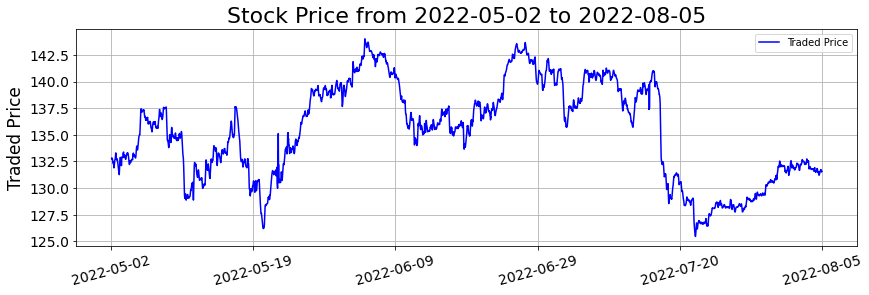

Sum of Returns: -5.477822396470259
Number of buy&sell trades executed: 156
Buy Price: 132.83413305227808, Sell Price: 132.90502222222221, Percentage Return: 0.05336668242961242%
Buy Price: 132.42926189163066, Sell Price: 132.662625, Percentage Return: 0.17621717816436774%
Buy Price: 137.43588659600127, Sell Price: 137.3193, Percentage Return: -0.08482980602001053%
Buy Price: 135.3599970573543, Sell Price: 136.0179, Percentage Return: 0.4860394185491457%
Buy Price: 136.00883166666665, Sell Price: 135.67993333333334, Percentage Return: -0.24182130623648365%
Buy Price: 136.0179, Sell Price: 135.64508192307693, Percentage Return: -0.2740948631930559%
Buy Price: 136.98322287284813, Sell Price: 137.51307500000001, Percentage Return: 0.3868007454049377%
Buy Price: 137.1629796851078, Sell Price: 137.5472, Percentage Return: 0.28011954521129845%
Buy Price: 134.93569392477937, Sell Price: 134.47566666666665, Percentage Return: -0.3409233277958031%
Buy Price: 134.74995514670238, Sell Price: 134.5

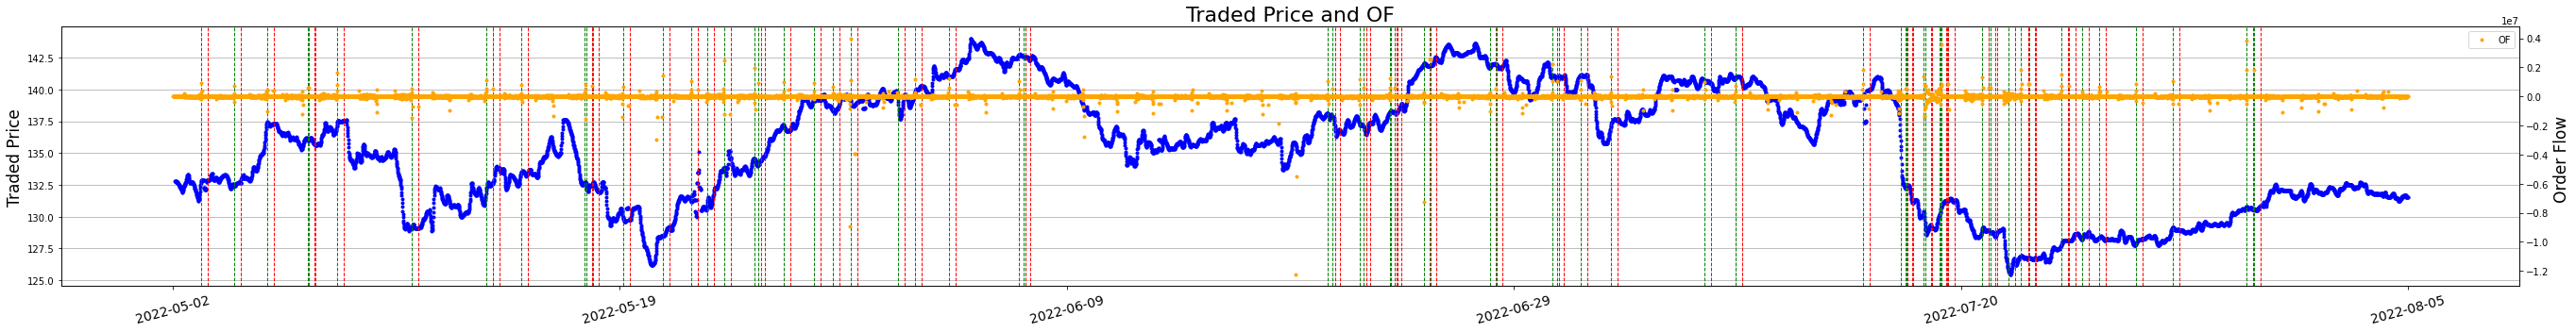

Total sum of returns: -5.477822396470259
Average Traded Price of Executed Trades: 134.59629248243212
Total number of trades executed: 156
Average Percentage Return: -4.069816705527189%


In [158]:
#*#*#*#**# Note - this is the version that includes trades that are executed at negative OFI values as well in order to the relationship between OFI vclaues and the returns 
#*#*#*#**# Note - this is the version that includes trades that are executed at negative OFI values as well in order to the relationship between OFI vclaues and the returns 
#*#*#*#**# Note - this is the version that includes trades that are executed at negative OFI values as well in order to the relationship between OFI vclaues and the returns 
#*#*#*#**# Note - this is the version that includes trades that are executed at negative OFI values as well in order to the relationship between OFI vclaues and the returns 

start = 0
end = 10000
num_ticks = 6

time = (df_final['FIVE_MIN_BUCKET'].dt.date.astype(str)).to_numpy()
time_segment = time[start:end]
tick_positions = np.linspace(0, len(time_segment) - 1, num_ticks, dtype=int)
tick_labels = [time_segment[pos] for pos in tick_positions]

label_color = 'black'
tick_color = 'black'

plt.figure(figsize=(14, 4))
plt.plot(df_final['TRADED_PRICE'][start:end].reset_index(drop=True), color='blue', label='Traded Price')
plt.title(f"Stock Price from {time_segment[0]} to {time_segment[-1]}", color=label_color, size=22)
plt.ylabel('Traded Price', color=label_color, size=17)
plt.tick_params(axis='y', labelcolor=tick_color)
plt.xticks(tick_positions, tick_labels, rotation=15, color=tick_color, fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

total_sum_returns = 0
total_money_risked = 0
total_trades_executed = 0

# Define condition_window if not already defined
condition_window = 1  # Example value, adjust as needed
ofi_sensitivity = 0.75
rolling_window_mean_ofi = 3
hold_period = 30

df_test = df_final[['OFI', 'TRADED_PRICE', 'RETURN' , 'VOLUME']][start:end].reset_index(drop=True)

df_test['OFI_ROLLING'] = df_test['OFI'].rolling(window=rolling_window_mean_ofi).mean()
df_test['RETURNS_XX_IDX_AHEAD'] = 0

ofi_std = df_final['OFI'].std()

condition_test = (df_test['OFI_ROLLING'] > ofi_sensitivity * ofi_std) & df_test['OFI_ROLLING'].shift(1).rolling(window=condition_window).apply(lambda x: all(x <= ofi_sensitivity * ofi_std))
condition_test_negative = (df_test['OFI_ROLLING'] < -ofi_sensitivity * ofi_std) & df_test['OFI_ROLLING'].shift(1).rolling(window=condition_window).apply(lambda x: all(x >= -ofi_sensitivity * ofi_std))

df_test.loc[condition_test, 'RETURNS_XX_IDX_AHEAD'] = df_test['TRADED_PRICE'].shift(-hold_period) - df_test['TRADED_PRICE']
df_test.loc[condition_test_negative, 'RETURNS_XX_IDX_AHEAD'] = df_test['TRADED_PRICE'].shift(-hold_period) - df_test['TRADED_PRICE']

df_test['PERCENTAGE_RETURN'] = (df_test['RETURNS_XX_IDX_AHEAD'] / df_test['TRADED_PRICE']) * 100

non_zero_count = (df_test['RETURNS_XX_IDX_AHEAD'] != 0).sum()

print(f"Sum of Returns: {df_test['RETURNS_XX_IDX_AHEAD'].sum()}")
print(f"Number of buy&sell trades executed: {non_zero_count}")

trades = df_test[df_test['RETURNS_XX_IDX_AHEAD'] != 0].copy()
trades['SELL_PRICE'] = trades['TRADED_PRICE'] + trades['RETURNS_XX_IDX_AHEAD']

for index, row in trades.iterrows():
    print(f"Buy Price: {row['TRADED_PRICE']}, Sell Price: {row['SELL_PRICE']}, Percentage Return: {row['PERCENTAGE_RETURN']}%")

total_sum_returns += trades['RETURNS_XX_IDX_AHEAD'].sum()
total_money_risked += trades['TRADED_PRICE'].sum()

df_test['BOUGHT'] = condition_test
df_test['SOLD'] = df_test['BOUGHT'].shift(hold_period)
df_test['SOLD'] = df_test['SOLD'].fillna(False)

fig, ax1 = plt.subplots(figsize=(38, 5))
ax1.plot(df_test['TRADED_PRICE'], '.', color='blue', label='Traded Price')
ax1.set_ylabel('Traded Price', color=label_color, size=17)
ax1.tick_params(axis='y', labelcolor=tick_color)
ax1.yaxis.grid(True)

ax2 = ax1.twinx()
ax2.plot(df_test['OFI'], '.', color='orange', label='OF')
ax2.set_ylabel('Order Flow ', color=label_color, size=17)
ax2.tick_params(axis='y', labelcolor=tick_color)
ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels, rotation=15, color=tick_color, fontsize=14)


condition_test_indices = df_test.index[condition_test]

for index in condition_test_indices:
    ax1.axvline(x=index, color='green', linestyle='--', linewidth=1.0)

sale_indices = df_test.index[df_test['SOLD']]

for index in sale_indices:
    ax1.axvline(x=index, color='red', linestyle='--', linewidth=1.0)

plt.title("Traded Price and OF", color=label_color, size=22)

fig.tight_layout()
plt.legend()
plt.show()

total_trades_executed += non_zero_count

avg_traded_price_of_buys = total_money_risked / total_trades_executed if total_trades_executed != 0 else 0

percentage_return_avg = (total_sum_returns / avg_traded_price_of_buys) * 100 if avg_traded_price_of_buys != 0 else 0

print(f"Total sum of returns: {total_sum_returns}")
print(f"Average Traded Price of Executed Trades: {avg_traded_price_of_buys}")
print(f"Total number of trades executed: {total_trades_executed}")
print(f"Average Percentage Return: {percentage_return_avg}%")

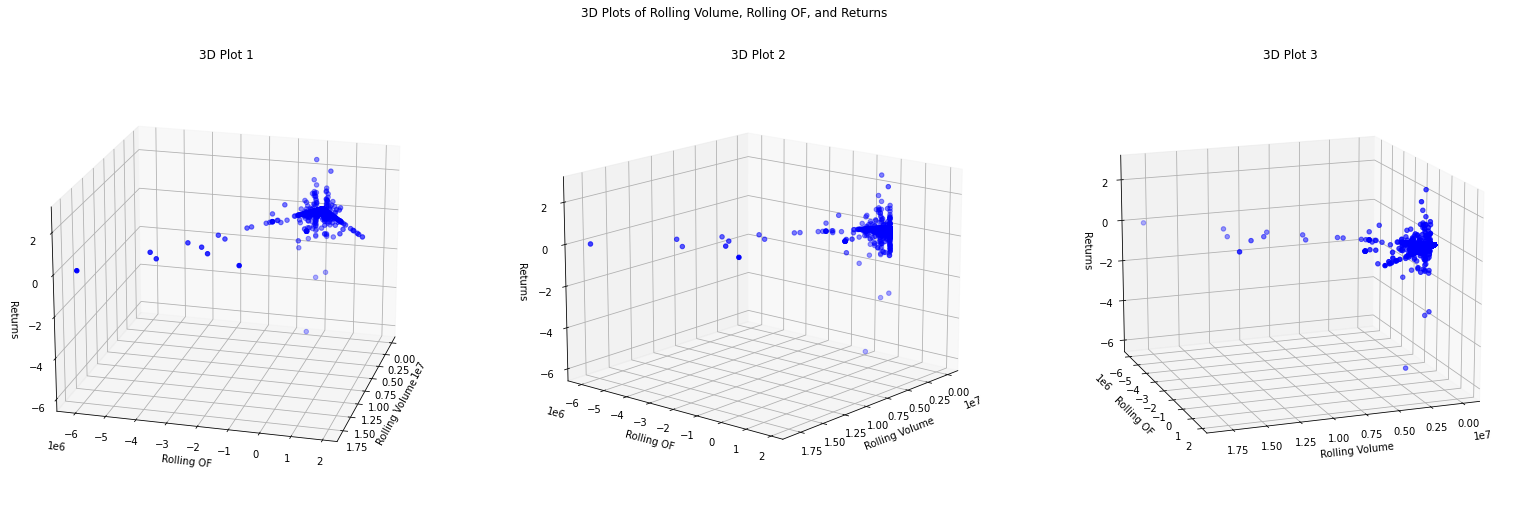

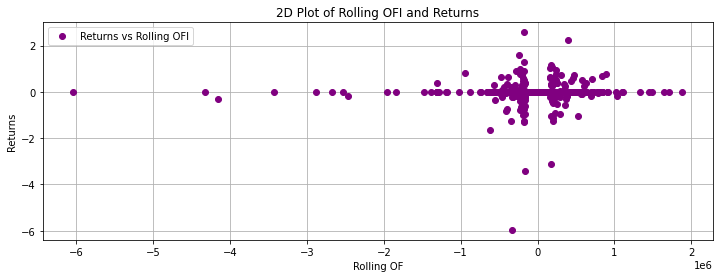

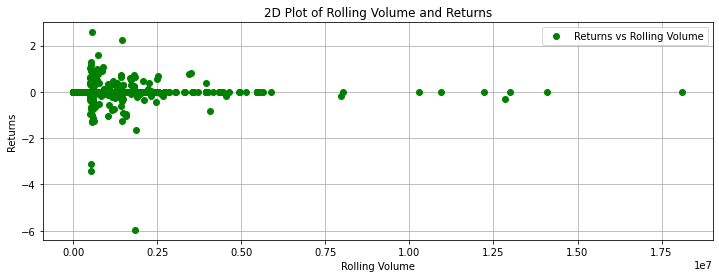

In [159]:
 # Assuming the rolling OFI uses a window of 20
df_test['ROLLING_VOLUME'] = df_test['VOLUME'].rolling(window=rolling_window_mean_ofi).sum()

# Create multiple 3D plots for the rolling OFI, rolling volume, and returns on the z-axis
fig = plt.figure(figsize=(27, 8))

# First 3D plot
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(df_test['ROLLING_VOLUME'], df_test['OFI_ROLLING'], df_test['RETURNS_XX_IDX_AHEAD'], c='b', marker='o')
ax1.set_xlabel('Rolling Volume')
ax1.set_ylabel('Rolling OF')
ax1.set_zlabel('Returns')
ax1.view_init(elev=20, azim=15)
ax1.set_title("3D Plot 1")

# Second 3D plot with a different angle
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(df_test['ROLLING_VOLUME'], df_test['OFI_ROLLING'], df_test['RETURNS_XX_IDX_AHEAD'], c='b', marker='o')
ax2.set_xlabel('Rolling Volume')
ax2.set_ylabel('Rolling OF')
ax2.set_zlabel('Returns')
ax2.view_init(elev=15, azim=40)
ax2.set_title("3D Plot 2")

# Third 3D plot with another different angle
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(df_test['ROLLING_VOLUME'], df_test['OFI_ROLLING'], df_test['RETURNS_XX_IDX_AHEAD'], c='b', marker='o')
ax3.set_xlabel('Rolling Volume')
ax3.set_ylabel('Rolling OF')
ax3.set_zlabel('Returns')
ax3.view_init(elev=15, azim=70)
ax3.set_title("3D Plot 3")

plt.suptitle("3D Plots of Rolling Volume, Rolling OF, and Returns")
plt.show()

# Create a 2D plot for the rolling OFI and returns
plt.figure(figsize=(12, 4))
plt.plot(df_test['OFI_ROLLING'].to_numpy(), df_test['RETURNS_XX_IDX_AHEAD'].to_numpy(), 'o', color='purple', label='Returns vs Rolling OFI')

# Set labels
plt.xlabel('Rolling OF')
plt.ylabel('Returns')

plt.title("2D Plot of Rolling OFI and Returns")
plt.grid(True)
plt.legend()
plt.show()

# Create a 2D plot for the rolling volume and returns
plt.figure(figsize=(12, 4))
plt.plot(df_test['ROLLING_VOLUME'].to_numpy(), df_test['RETURNS_XX_IDX_AHEAD'].to_numpy(), 'o', color='green', label='Returns vs Rolling Volume')

# Set labels
plt.xlabel('Rolling Volume')
plt.ylabel('Returns')

plt.title("2D Plot of Rolling Volume and Returns")
plt.grid(True)
plt.legend()
plt.show()

# Grid Search Method  - Optimizing Parameters 


The 4 parameters that are variable are of_sensitivity, hold_period, rolling_window_mean_of, and condition_window.
 
- of_sensitivity: This variable represents the sensitivity threshold for the Order Flow rolling mean

- hold_period: This variable represents the number of periods to hold the position before selling

- rolling_window_mean_of: This variable represents the window size for calculating the rolling mean of the OF

- condition_window: This variable represents the window size where we want to execute one trade at a time - this serves to adjust the number of trades executed



In [160]:

def calculate_sum_of_percentage_returns(start, end, ofi_sensitivity, hold_period, rolling_window_mean_ofi, condition_window):
    df_test = df_final[['OFI', 'TRADED_PRICE', 'RETURN', 'VOLUME']][start:end].reset_index(drop=True)
    df_test['OFI_ROLLING'] = df_test['OFI'].rolling(window=rolling_window_mean_ofi).mean()
    df_test['RETURNS_XX_IDX_AHEAD'] = 0
    # Calculate the standard deviation of the OFI
    ofi_std = df_final['OFI'][0:4000].std()

    condition_test = (df_test['OFI_ROLLING'] > ofi_sensitivity*ofi_std) & df_test['OFI_ROLLING'].shift(1).rolling(window=condition_window).apply(lambda x: all(x <= ofi_sensitivity*ofi_std))
    df_test.loc[condition_test, 'RETURNS_XX_IDX_AHEAD'] = df_test['TRADED_PRICE'].shift(-hold_period) - df_test['TRADED_PRICE']
    
    # Calculate total returns
    total_returns = df_test['RETURNS_XX_IDX_AHEAD'].sum()

    max_buy_price = df_test.loc[condition_test, 'TRADED_PRICE'].max()
    
    # Calculate average traded price of the buys
    avg_traded_price_of_buys = df_test.loc[condition_test, 'TRADED_PRICE'].mean() if condition_test.any() else 0
    
    non_zero_count = (df_test['RETURNS_XX_IDX_AHEAD'] != 0).sum()

    percentage_return_avg = (total_returns / avg_traded_price_of_buys) * 100 if avg_traded_price_of_buys != 0 else 0

    return_relative_to_max_buy_price = (total_returns / max_buy_price) * 100

    


    
    return total_returns, avg_traded_price_of_buys, non_zero_count, percentage_return_avg , max_buy_price , return_relative_to_max_buy_price


In [161]:

from sklearn.model_selection import ParameterGrid
import numpy as np

def grid_search_ofi_parameters(start, end, ofi_sensitivity_interval, hold_period_interval, rolling_window_mean_ofi_interval, condition_window_interval, num_points_ofi, num_points_hold, num_points_rolling, num_points_condition):
    # Create the parameter grid using linspace with different number of points for each parameter
    param_grid = {
        'ofi_sensitivity': np.linspace(ofi_sensitivity_interval[0], ofi_sensitivity_interval[1], num_points_ofi),
        'hold_period': np.linspace(hold_period_interval[0], hold_period_interval[1], num_points_hold, dtype=int),
        'rolling_window_mean_ofi': np.linspace(rolling_window_mean_ofi_interval[0], rolling_window_mean_ofi_interval[1], num_points_rolling, dtype=int),
        'condition_window': np.linspace(condition_window_interval[0], condition_window_interval[1], num_points_condition, dtype=int)
    }
    
    results = []
    
    for params in ParameterGrid(param_grid):
        ofi_sensitivity = params['ofi_sensitivity']
        hold_period = params['hold_period']
        rolling_window_mean_ofi = params['rolling_window_mean_ofi']
        condition_window = params['condition_window']
        
        sum_returns, avg_traded_price_of_buys, non_zero_count, percentage_return_avg, max_buy_price, return_relative_to_max_buy_price = calculate_sum_of_percentage_returns(start, end, ofi_sensitivity, hold_period, rolling_window_mean_ofi, condition_window)
        
        results.append((params, sum_returns, percentage_return_avg, avg_traded_price_of_buys, non_zero_count, max_buy_price, return_relative_to_max_buy_price))
    
    # Sort results by return_relative_to_max_buy_price in descending order and get the top 5
    top_results = sorted(results, key=lambda x: x[6], reverse=True)[:5]
    
    return top_results

# Example usage with interval sizes and different number of points for each parameter
ofi_sensitivity_interval = (0, 3)
hold_period_interval = (10, 60)
rolling_window_mean_ofi_interval = (3, 50)
condition_window_interval = (1, 60)
num_points_ofi = 9
num_points_hold = 4
num_points_rolling = 4
num_points_condition = 4

top_params = grid_search_ofi_parameters(
    start=4000, 
    end=8000, 
    ofi_sensitivity_interval=ofi_sensitivity_interval, 
    hold_period_interval=hold_period_interval, 
    rolling_window_mean_ofi_interval=rolling_window_mean_ofi_interval, 
    condition_window_interval=condition_window_interval,
    num_points_ofi=num_points_ofi,
    num_points_hold=num_points_hold,
    num_points_rolling=num_points_rolling,
    num_points_condition=num_points_condition
)

for i, (params, sum_returns, percentage_return_avg, avg_traded_price_of_buys, total_trades, max_buy_price, return_relative_to_max_buy_price) in enumerate(top_params, start=1):
    print(f"Top {i} Parameters: {params}")
    print(f"Sum of Returns: {sum_returns}")
    print(f"Percentage Average Returns: {percentage_return_avg}")
    print(f"Average Traded Price of Buys: {avg_traded_price_of_buys}")
    print(f"Total Trades: {total_trades}")
    print(f"Max Buy Price: {max_buy_price}")
    print(f"Returns relative to max buy price: {return_relative_to_max_buy_price}%\n")


Top 1 Parameters: {'condition_window': 1, 'hold_period': 10, 'ofi_sensitivity': 0.0, 'rolling_window_mean_ofi': 50}
Sum of Returns: 8.50211055844784
Percentage Average Returns: 6.152152281130697
Average Traded Price of Buys: 138.19733598800397
Total Trades: 76
Max Buy Price: 143.63906490240566
Returns relative to max buy price: 5.919079579238786%

Top 2 Parameters: {'condition_window': 1, 'hold_period': 10, 'ofi_sensitivity': 0.75, 'rolling_window_mean_ofi': 18}
Sum of Returns: 1.4529407780019596
Percentage Average Returns: 1.0519449235809881
Average Traded Price of Buys: 138.119472363241
Total Trades: 4
Max Buy Price: 141.839
Returns relative to max buy price: 1.024359152279669%

Top 3 Parameters: {'condition_window': 1, 'hold_period': 10, 'ofi_sensitivity': 0.375, 'rolling_window_mean_ofi': 34}
Sum of Returns: 0.37626529581746126
Percentage Average Returns: 0.2726524602144833
Average Traded Price of Buys: 138.00179742426326
Total Trades: 4
Max Buy Price: 141.91500000000002
Returns re

---
# **Strategy Demo** 
--- 

## - ***Green line*** : reresents that a trade is executed
## - ***Red line*** : represents that the sell has a been executed

## In short: 

## The algorithm 'waits' for a buy signal (based on the OFI) , then executes a trade and sells it after the defined hold period. This is what happens whenever there is a buy signal and the hold period is held constant for simplicity. 

In [162]:
def create_intervals(start, end, interval_size):
    return [(i, min(i + interval_size, end)) for i in range(start, end, interval_size)]

def analyze_intervals(start, end, ofi_sensitivity, hold_period, interval_size, rolling_window_mean_ofi, condition_window, num_ticks):
    intervals = create_intervals(start, end, interval_size)
    time = (df_final['FIVE_MIN_BUCKET'].dt.date.astype(str)).to_numpy()
    time_segment = time[start:end]
    tick_positions = np.linspace(0, len(time_segment) - 1, num_ticks, dtype=int)
    tick_labels = [time_segment[pos] for pos in tick_positions]

    label_color = 'black'
    tick_color = 'black'

    plt.figure(figsize=(14, 4))
    plt.plot(df_final['TRADED_PRICE'][start:end].reset_index(drop=True), color='blue', label='Traded Price')
    plt.title(f"Stock Price from {time_segment[0]} to {time_segment[-1]}", color=label_color, size=22)
    plt.ylabel('Traded Price', color=label_color, size=17)
    plt.tick_params(axis='y', labelcolor=tick_color)
    plt.xticks(tick_positions, tick_labels, rotation=15, color=tick_color, fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(True)
    plt.legend()
    plt.show()

    total_sum_returns = 0
    total_money_risked = 0
    total_trades_executed = 0

    for interval_start, interval_end in intervals:
        time = (df_final['FIVE_MIN_BUCKET'].astype(str)).to_numpy()
        time_segment = time[interval_start:interval_end]
        tick_positions = np.linspace(0, len(time_segment) - 1, num_ticks, dtype=int)
        tick_labels = [time_segment[pos] for pos in tick_positions]

        df_test = df_final[['OFI', 'TRADED_PRICE', 'RETURN']][interval_start:interval_end].reset_index(drop=True)

        df_test['OFI_ROLLING'] = df_test['OFI'].rolling(window=rolling_window_mean_ofi).mean()
        df_test['RETURNS_XX_IDX_AHEAD'] = 0

        ofi_std = df_final['OFI'][0:4000].std()

        condition_test = (df_test['OFI_ROLLING'] > ofi_sensitivity * ofi_std) & df_test['OFI_ROLLING'].shift(1).rolling(window=condition_window).apply(lambda x: all(x <= ofi_sensitivity * ofi_std))

        df_test.loc[condition_test, 'RETURNS_XX_IDX_AHEAD'] = df_test['TRADED_PRICE'].shift(-hold_period) - df_test['TRADED_PRICE']
        df_test['PERCENTAGE_RETURN'] = (df_test['RETURNS_XX_IDX_AHEAD'] / df_test['TRADED_PRICE'].replace(0, np.nan)) * 100

        non_zero_count = (df_test['RETURNS_XX_IDX_AHEAD'] != 0).sum()

        print(f"Sum of Returns: {df_test['RETURNS_XX_IDX_AHEAD'].sum()}")
        print(f"Number of buy&sell trades executed: {non_zero_count}")

        trades = df_test[df_test['RETURNS_XX_IDX_AHEAD'] != 0].copy()
        trades['SELL_PRICE'] = trades['TRADED_PRICE'] + trades['RETURNS_XX_IDX_AHEAD']

        for index, row in trades.iterrows():
            print(f"Buy Price: {row['TRADED_PRICE']}, Sell Price: {row['SELL_PRICE']}, Percentage Return: {row['PERCENTAGE_RETURN']}%")

        total_sum_returns += trades['RETURNS_XX_IDX_AHEAD'].sum()
        total_money_risked += trades['TRADED_PRICE'].sum()

        df_test['BOUGHT'] = condition_test
        df_test['SOLD'] = df_test['BOUGHT'].shift(hold_period)
        df_test['SOLD'] = df_test['SOLD'].fillna(False)

        fig, ax1 = plt.subplots(figsize=(35, 5))
        ax1.plot(df_test['TRADED_PRICE'], '.', color='blue', label='Traded Price')
        ax1.set_ylabel('Traded Price', color=label_color, size=17)
        ax1.tick_params(axis='y', labelcolor=tick_color)
        ax1.yaxis.grid(True)

        ax2 = ax1.twinx()
        ax2.plot(df_test['OFI'], '.', color='orange', label='OF')
        ax2.set_ylabel('Order Flow ', color=label_color, size=17)
        ax2.tick_params(axis='y', labelcolor=tick_color)
        ax1.set_xticks(tick_positions)
        ax1.set_xticklabels(tick_labels, rotation=15, color=tick_color, fontsize=14)
        plt.yticks(fontsize=14)

        condition_test_indices = df_test.index[condition_test]

        for index in condition_test_indices:
            ax1.axvline(x=index, color='green', linestyle='--', linewidth=1.0)

        sale_indices = df_test.index[df_test['SOLD']]

        for index in sale_indices:
            ax1.axvline(x=index, color='red', linestyle='--', linewidth=1.0)

        plt.title("Traded Price and OF", color=label_color, size=22)

        fig.tight_layout()
        plt.legend()
        plt.show()

        total_trades_executed += non_zero_count

    avg_traded_price_of_buys = total_money_risked / total_trades_executed if total_trades_executed != 0 else 0

    percentage_return_avg = (total_sum_returns / avg_traded_price_of_buys) * 100 if avg_traded_price_of_buys != 0 else 0

    max_buy_price = trades['TRADED_PRICE'].max() if not trades.empty else 0
    returns_relative_to_max_buy_price = (total_sum_returns / max_buy_price * 100) if max_buy_price != 0 else 0

    print(f"Total sum of returns across all intervals: {total_sum_returns}")
    print(f"Average Traded Price of Executed Trades: {avg_traded_price_of_buys}")
    print(f"Total number of trades executed across all intervals: {total_trades_executed}")
    print(f"Average Percentage Return: {percentage_return_avg}%")
    print(f"Returns relative to max buy price: {returns_relative_to_max_buy_price}%")
    print(f"Max Buy Price: {max_buy_price}")

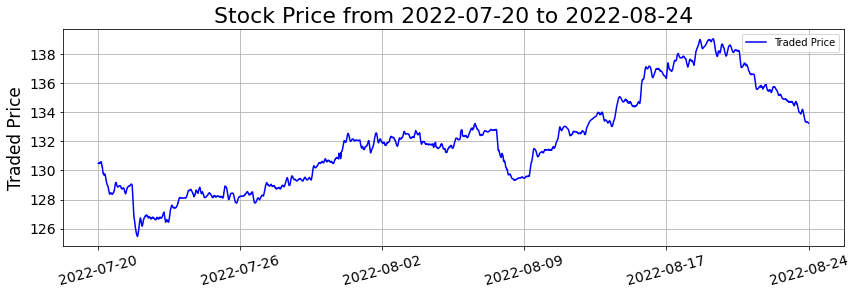

Sum of Returns: 7.466793112437358
Number of buy&sell trades executed: 81
Buy Price: 128.6379964238972, Sell Price: 129.16140374928668, Percentage Return: 0.4068839222780766%
Buy Price: 129.04103311148154, Sell Price: 128.93995661326213, Percentage Return: -0.0783289592327511%
Buy Price: 126.35485667063816, Sell Price: 126.47654627330067, Percentage Return: 0.09630781583624823%
Buy Price: 127.14362210058752, Sell Price: 126.4444070091711, Percentage Return: -0.5499411451903169%
Buy Price: 128.19605016686896, Sell Price: 128.62172148023845, Percentage Return: 0.3320471362537364%
Buy Price: 128.25663789353447, Sell Price: 128.42020911516775, Percentage Return: 0.12753431270282975%
Buy Price: 128.47027841869124, Sell Price: 128.86675052237916, Percentage Return: 0.30860998245508886%
Buy Price: 128.88556454496174, Sell Price: 128.55981898840008, Percentage Return: -0.25274014022572744%
Buy Price: 128.82019189411506, Sell Price: 128.15754927950903, Percentage Return: -0.5143934385307339%
Buy

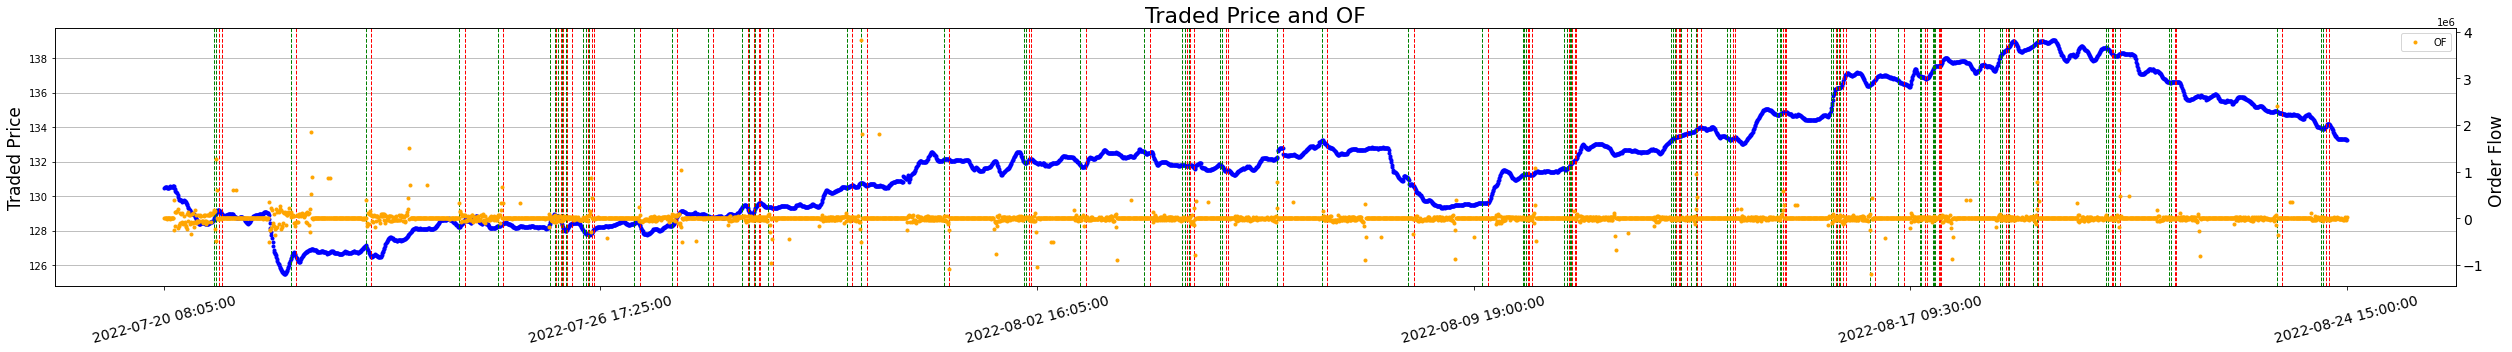

Total sum of returns across all intervals: 7.466793112437358
Average Traded Price of Executed Trades: 132.69203358832058
Total number of trades executed across all intervals: 81
Average Percentage Return: 5.627160056649081%
Returns relative to max buy price: 5.376245347093047%
Max Buy Price: 138.8849025737763


In [163]:
analyze_intervals(start = 8000, end = 12000, ofi_sensitivity = 0.0, hold_period = 10, rolling_window_mean_ofi = 50, condition_window = 1 , num_ticks=6, interval_size=5000)